In [1]:
#######################################
## downstream of ilastik analysis
## 2rd batch of images, most of images were manually segmented in ilastik
#######################################

In [1]:
import cv2

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import copy

from skimage.io import imread
from skimage.io import imsave
from skimage import filters
from skimage import morphology
from skimage import measure
import numpy as np
import matplotlib.pyplot as plt
from skimage.io import imread, imshow
from skimage.color import rgb2gray, rgb2hsv
from skimage.filters import threshold_otsu
#from scipy import ndimage as ndi
from skimage import (exposure, feature, filters, io, measure,
                      morphology, restoration, segmentation, transform,
                      util)

import numpy as np
import matplotlib.pyplot as plt
from skimage import io, measure, morphology, color
from skimage.draw import rectangle_perimeter

In [3]:
def find_max_gap(idx_col):
    import numpy as np
    
    index_gap = 1
    gap_size2save = 0
    gap_idx_2save = []
    gap_size = 0
    gap_idx = []
    
    nb_id = 0
    for idx in idx_col:
        nb_id = nb_id + 1;
        #print(idx)
        if gap_size == 0: ## gap starting point
            gap_idx.append(idx)
            gap_size = gap_size + 1
            idx_prev = idx
        else:
            diff = idx - idx_prev
            
            if diff > 1 or nb_id == len(idx_col): ## gap ending point
                #print(idx)
                if gap_size2save == 0:
                    gap_size2save = gap_size
                    gap_idx_2save = gap_idx
                else:
                    if gap_size >= gap_size2save:
                        gap_size2save = gap_size
                        gap_idx_2save = gap_idx
                
                gap_size = 0
                gap_idx = []
                index_gap = index_gap + 1
                
            else:
                gap_size = gap_size + 1 ## increase the gap
                gap_idx.append(idx)
                idx_prev = idx
    if index_gap == 1: # in case there is one gap
        gap_size2save = gap_size
        gap_idx_2save = gap_idx
    
    return(gap_idx_2save)

In [4]:
inputDir = "/Volumes/groups/tanaka/People/current/jiwang/projects/image_analysis/axolotl_limb_CSD/export190326/processed"
#inputDir = "/Volumes/groups/tanaka/People/current/jiwang/projects/image_analysis/axolotl_limb_CSD/processed"
fileName = '4w-1x-LNP-TIG-2_Probabilities.tif'
fileName = '4w-1x-LNP2-1_Probabilities.tif'
#fileName = '675953-LNP1-limb1_Probabilities.tif'
#fileName = '675911-LNP3-limb2_Probabilities.tif'

#fileName = "675907-LNP4-limb2_Probabilities.tif"
#fileName = "675911-LNP3-limb1_Probabilities.tif"
#fileName = '675911-LNP3-limb2_Probabilities.tif'
#fileName = '675982-LNP1-limb1_Probabilities.tif'
#fileName = "675930-LNP3-limb2_Probabilities.tif"
#fileName = "675948-LNP2-limb1_Probabilities.tif"
#fileName = "675969-LNP3-limb1_Probabilities.tif"
#fileName = "676002-LNP2-limb1_Probabilities.tif"
#fileName = "675911-LNP3-limb2_Probabilities.tif"

path_results = '/Volumes/groups/tanaka/People/current/jiwang/projects/image_analysis/axolotl_limb_CSD/export190326/results/'
outDir = path_results

if not os.path.exists(outDir):
    os.makedirs(outDir)

print(outDir)
print(fileName)

/Volumes/groups/tanaka/People/current/jiwang/projects/image_analysis/axolotl_limb_CSD/export190326/results/
4w-1x-LNP2-1_Probabilities.tif


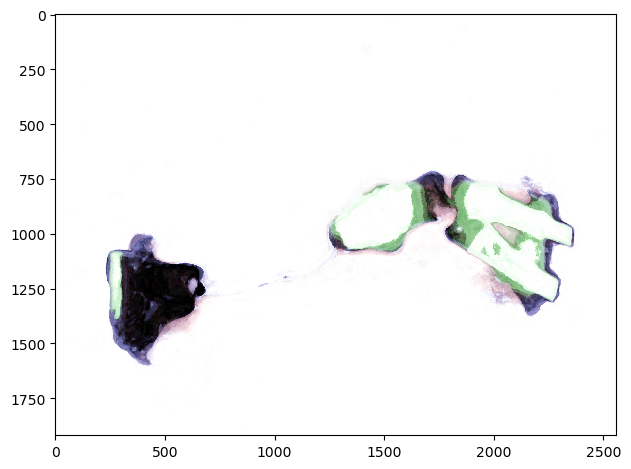

In [5]:
# Load Original Image
img_prob = imread(os.path.join(inputDir, fileName))
imshow(img_prob)

In [14]:
img_prob.shape

(1920, 2560, 4)

In [16]:
np.max(img_prob[:, :, 1] + img_prob[:, :, 3])

np.float32(1.0)

In [17]:
if img_prob.shape[2] > 3: 
    bone_mask = (img_prob[:, :, 1] +  img_prob[:, :, 3])> 0.5
else:
    bone_mask = img_prob[:, :, 1] > 0.5

cart_mask = img_prob[:, :, 2] > 0.5;

In [18]:
#imshow(img_prob[:, :, 0] > 0.5)

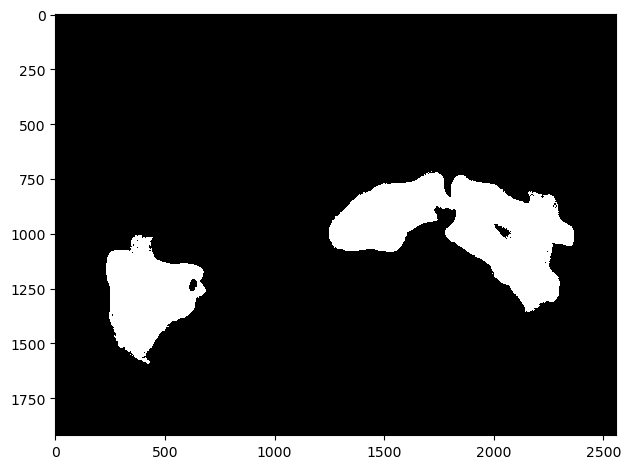

In [19]:
imshow(bone_mask)

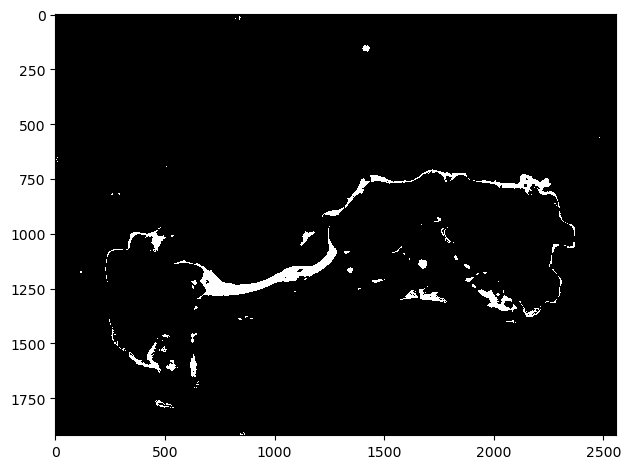

In [20]:
imshow(cart_mask)

In [21]:
bone_mask = morphology.remove_small_objects(bone_mask, min_size=64)

In [22]:
rowsum = bone_mask.sum(axis=1);
idx_row = np.where(rowsum > 0)
colsum = bone_mask.sum(axis=0);
idx_col = np.where(colsum > 0)

In [23]:
bone_mask_cropped = bone_mask[np.min(idx_row):np.max(idx_row), np.min(idx_col):np.max(idx_col)]
cart_mask_cropped = cart_mask[np.min(idx_row):np.max(idx_row), np.min(idx_col):np.max(idx_col)]

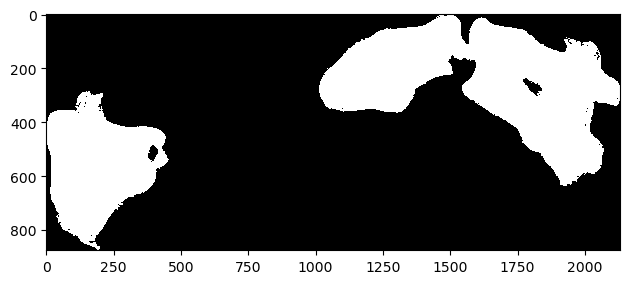

In [24]:
imshow(bone_mask_cropped, cmap="gray")

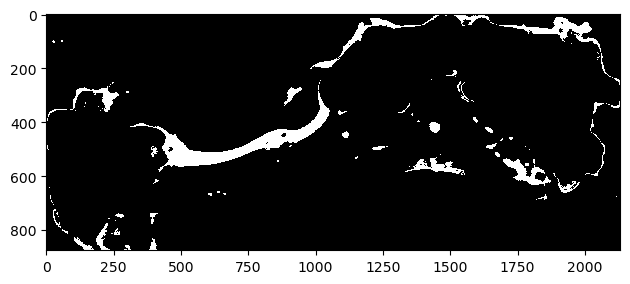

In [25]:
imshow(cart_mask_cropped, cmap="gray")

In [26]:
colsum = bone_mask_cropped.sum(axis=0);
idx_col = np.where(colsum == 0)
colsum2 = cart_mask_cropped.sum(axis = 0)

In [27]:
gap_idx = find_max_gap(idx_col[0])
length_bone = len(gap_idx)

In [28]:
np.min(gap_idx)

np.int64(455)

In [29]:
bone_len = 100
if np.min(gap_idx) < bone_len:
    bone_len = np.min(gap_idx)
bone_mask_gap = bone_mask_cropped[:, (np.min(gap_idx)-bone_len):(np.max(gap_idx) + bone_len)]
cart_mask_gap = cart_mask_cropped[:, (np.min(gap_idx)):(np.max(gap_idx))]
#cart_mask_gap = cart_mask_cropped[:, (np.min(gap_idx)):(np.max(gap_idx))]

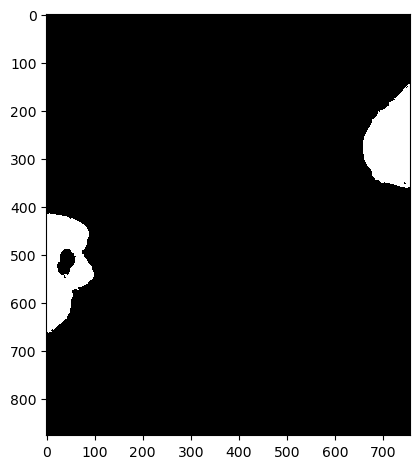

In [30]:
imshow(bone_mask_gap, cmap="gray")

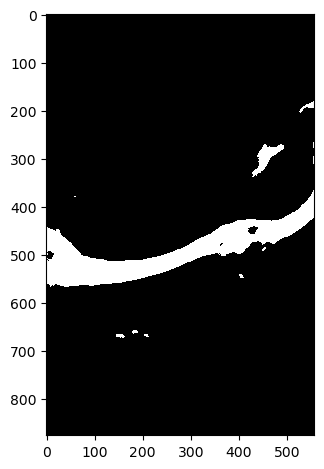

In [31]:
imshow(cart_mask_gap, cmap="gray")

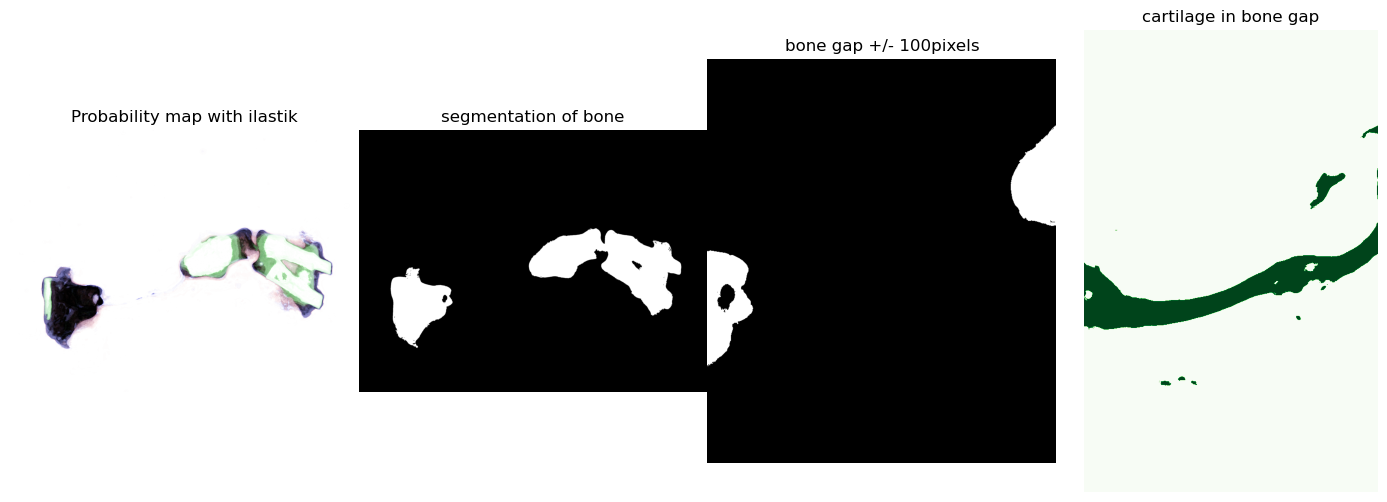

In [32]:
# Plot
fig, ax = plt.subplots(1, 4, figsize=(18, 6))
fig.subplots_adjust(wspace=0)

ax[0].set_title("Probability map with ilastik")
ax[0].imshow(img_prob)
ax[0].set_axis_off()
ax[1].set_title("segmentation of bone")
ax[1].imshow(bone_mask, cmap='gray')
ax[1].set_axis_off()
ax[2].set_title("bone gap +/- 100pixels")
ax[2].imshow(bone_mask_gap, cmap='gray')
ax[2].set_axis_off()

ax[3].set_title("cartilage in bone gap")
ax[3].imshow(cart_mask_gap, cmap='Greens')
ax[3].set_axis_off()


In [35]:
colsum_cart = cart_mask_gap.sum(axis=0);
idx_col_cart = np.where(colsum_cart == 0)

gap_idx_cart = find_max_gap(idx_col_cart[0])
gap_idx_cart
idx_col_cart

(array([], dtype=int64),)

In [36]:
colsum_cart = cart_mask_gap.sum(axis=0);
idx_col_cart = np.where(colsum_cart == 0)
gap_idx_cart = find_max_gap(idx_col_cart[0])
length_gapCart = len(gap_idx_cart)
length_gapCart1 = len(idx_col_cart[0])
print(length_gapCart, length_gapCart1)

0 0


In [37]:
from scipy.signal import argrelextrema
pct_cutPlan = 1/3

In [38]:
bone_left = bone_mask_cropped[:, (np.min(gap_idx)-bone_len):(np.min(gap_idx))]
colsum_left = bone_left.sum(axis=0)
colsum_left = colsum_left[::-1]
#print(colsum_left[0:99])
diff = abs(colsum_left - np.max(colsum_left) * pct_cutPlan)
#print(diff)
#print(diff.argmin(axis=0))
dist_left = argrelextrema(diff, np.less)[0][0]
print(dist_left)

15


In [39]:
bone_right = bone_mask_cropped[:, (np.max(gap_idx)):(np.max(gap_idx) + bone_len)]
colsum_right = bone_right.sum(axis=0)
#colsum_right = colsum_right[::-1]
#print(colsum_right)
diff_right = abs(colsum_right - np.max(colsum_right) * pct_cutPlan)
#print(diff.argmin(axis=0))
dist_right = argrelextrema(diff_right, np.less)[0][0]

print(dist_right)

10


In [40]:
cart_mask_gap = cart_mask_cropped[:, (np.min(gap_idx)-dist_left):(np.max(gap_idx) + dist_right)]
colsum_cart = cart_mask_gap.sum(axis=0);
idx_col_cart = np.where(colsum_cart == 0)
gap_idx_cart2 = find_max_gap(idx_col_cart[0])
length_gapCart2 = len(gap_idx_cart2)

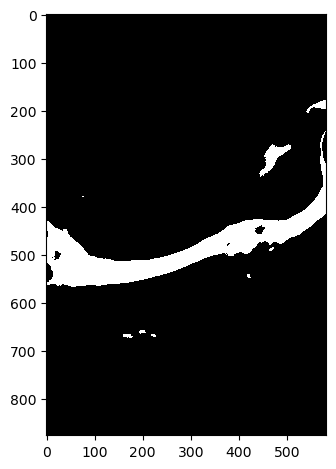

In [41]:
imshow(cart_mask_gap, cmap="gray")

In [42]:
print(length_gapCart, length_bone, dist_left, dist_right)
pct_closed = 1 - length_gapCart/(length_bone + dist_left + dist_right)
print(pct_closed)

0 558 15 10
1.0


In [43]:
print(length_gapCart2, length_bone, dist_left, dist_right)
pct_closed = 1 - length_gapCart2/(length_bone + dist_left + dist_right)
print(pct_closed)

0 558 15 10
1.0


In [212]:
##################################################
### batch calculation of all images 
##################################################

In [44]:
inputDir = "/Volumes/groups/tanaka/People/current/jiwang/projects/image_analysis/axolotl_limb_CSD/export190326/processed"

path_results = '/Volumes/groups/tanaka/People/current/jiwang/projects/image_analysis/axolotl_limb_CSD/export190326/results/'

outDir = path_results

if not os.path.exists(outDir):
    os.makedirs(outDir)

print(outDir)


/Volumes/groups/tanaka/People/current/jiwang/projects/image_analysis/axolotl_limb_CSD/export190326/results/


In [45]:
data = {"image": [], "bone_gap":[],  "left_cuttingPlan":[], "right_cuttingPlan":[], 
        "cartilage_boneGap":[],  "cartilage_boneGap_2":[], "cartilage_boneCutting":[],   "cartilage_boneCutting_2":[],  
         "pct_closure_1":[],  "pct_closure_2":[], "pct_closure_3":[], "pct_closure_4":[]
       }

df = pd.DataFrame(data)

In [46]:
df

,image,bone_gap,left_cuttingPlan,right_cuttingPlan,cartilage_boneGap,cartilage_boneGap_2,cartilage_boneCutting,cartilage_boneCutting_2,pct_closure_1,pct_closure_2,pct_closure_3,pct_closure_4


4w-1x-LNP-TIG-1_Probabilities.tif (1920, 2560, 3)
0.292332268370607 0.29073482428115016  0.292332268370607  0.29073482428115016
4w-1x-LNP-TIG-2_Probabilities.tif (1920, 2560, 3)
1.0 1.0  1.0  1.0
4w-1x-LNP-WG-1_Probabilities.tif (1920, 2560, 4)
0.9671361502347418 0.9624413145539906  0.9671361502347418  0.9624413145539906
4w-1x-LNP-WG-2_Probabilities.tif (1920, 2560, 4)
1.0 1.0  1.0  1.0
4w-1x-LNP-WTIG-1_Probabilities.tif (1920, 2560, 3)
1.0 1.0  1.0  1.0
4w-1x-LNP-WTIG-2_Probabilities.tif (1920, 2560, 3)
1.0 1.0  1.0  1.0
4w-1x-LNP1-2_Probabilities.tif (1920, 2560, 4)
0.725206611570248 0.6632231404958677  0.725206611570248  0.6487603305785123
4w-1x-LNP1-4_Probabilities.tif (1920, 2560, 3)
0.20853080568720384 0.20616113744075826  0.20853080568720384  0.20616113744075826
4w-1x-LNP1-5_Probabilities.tif (1920, 2560, 4)
1.0 1.0  1.0  1.0
4w-1x-LNP2-1_Probabilities.tif (1920, 2560, 4)
1.0 1.0  1.0  1.0
4w-1x-LNP2-2_Probabilities.tif (1920, 2560, 4)
1.0 1.0  1.0  1.0
4w-1x-LNP2-3_Probabilitie

/var/folders/ld/7f_9j5n17vs69r90p179ws240000gp/T/ipykernel_20377/1786462152.py:82: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(1, 4, figsize=(24, 6))


1.0 1.0  1.0  1.0
4w-1x-LNP4-3_Probabilities.tif (1920, 2560, 3)
1.0 1.0  1.0  1.0
4w-1x-LNP4-4_Probabilities.tif (1920, 2560, 4)
1.0 1.0  1.0  1.0
4w-1x-LNP4-5_Probabilities.tif (1920, 2560, 4)
1.0 1.0  1.0  1.0
4w-1x-LNP4-6_Probabilities.tif (1920, 2560, 3)
1.0 1.0  1.0  1.0
4w-1x-LNP5-1_Probabilities.tif (1920, 2560, 3)
0.23976608187134507 0.23684210526315785  0.22807017543859653  0.22514619883040932
4w-1x-LNP5-2_Probabilities.tif (1920, 2560, 3)
0.9420289855072463 0.9396135265700483  0.9420289855072463  0.9396135265700483
4w-1x-LNP5-3_Probabilities.tif (1920, 2560, 3)
0.27994011976047906 0.2784431137724551  0.27994011976047906  0.2784431137724551
4w-1x-LNP5-4_Probabilities.tif (1920, 2560, 4)
0.08771929824561409 0.08187134502923976  0.011695906432748537  0.005847953216374324
4w-1x-LNP5-5_Probabilities.tif (1920, 2560, 3)
0.11585365853658536 0.058943089430894324  0.1077235772357723  0.05081300813008127
4w-1x-LNP5-6_Probabilities.tif (1920, 2560, 3)
1.0 1.0  1.0  1.0


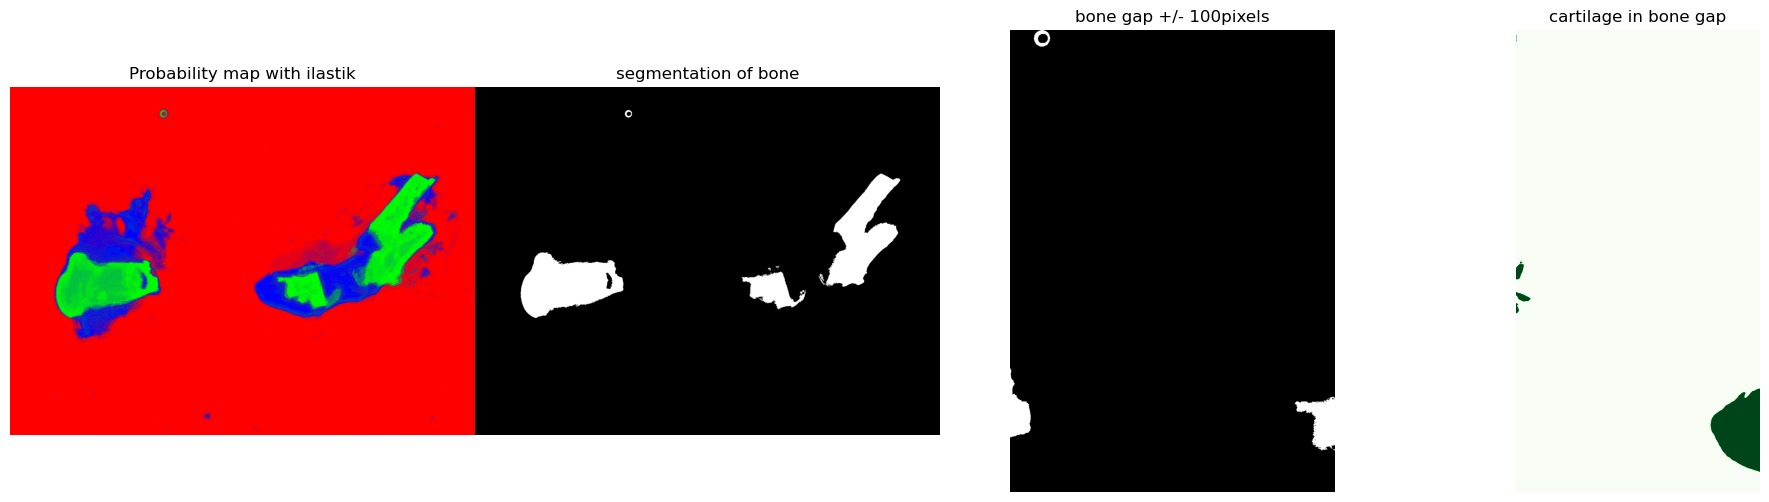

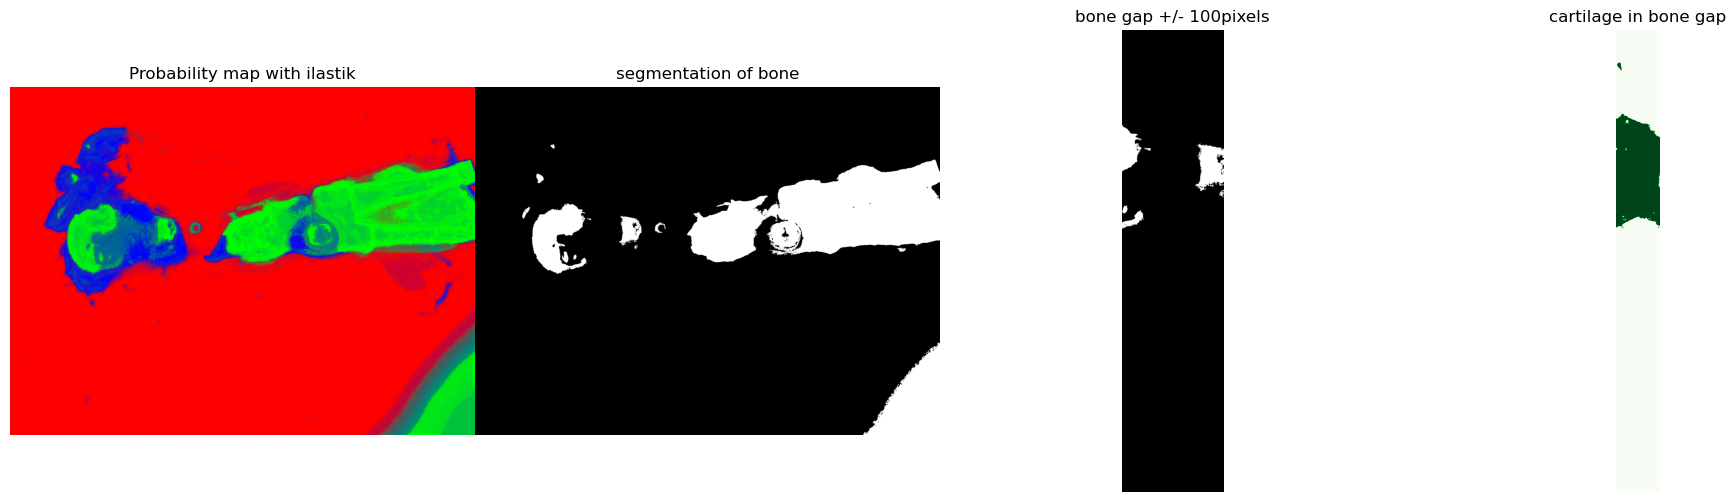

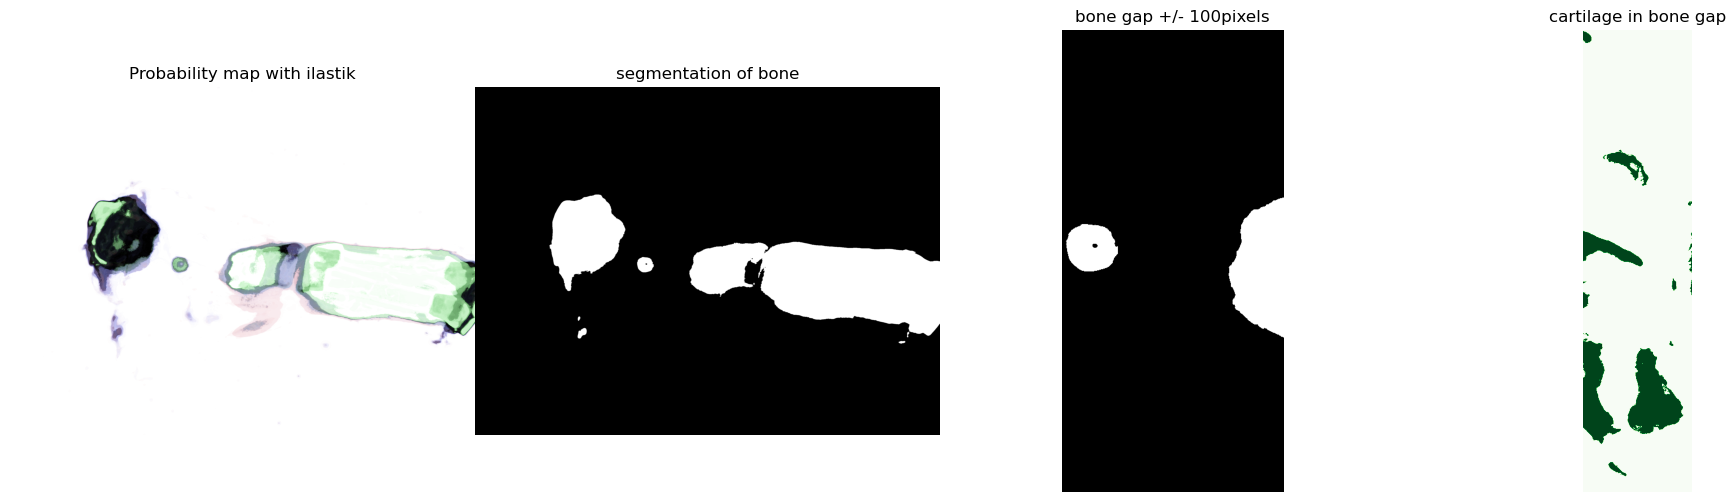

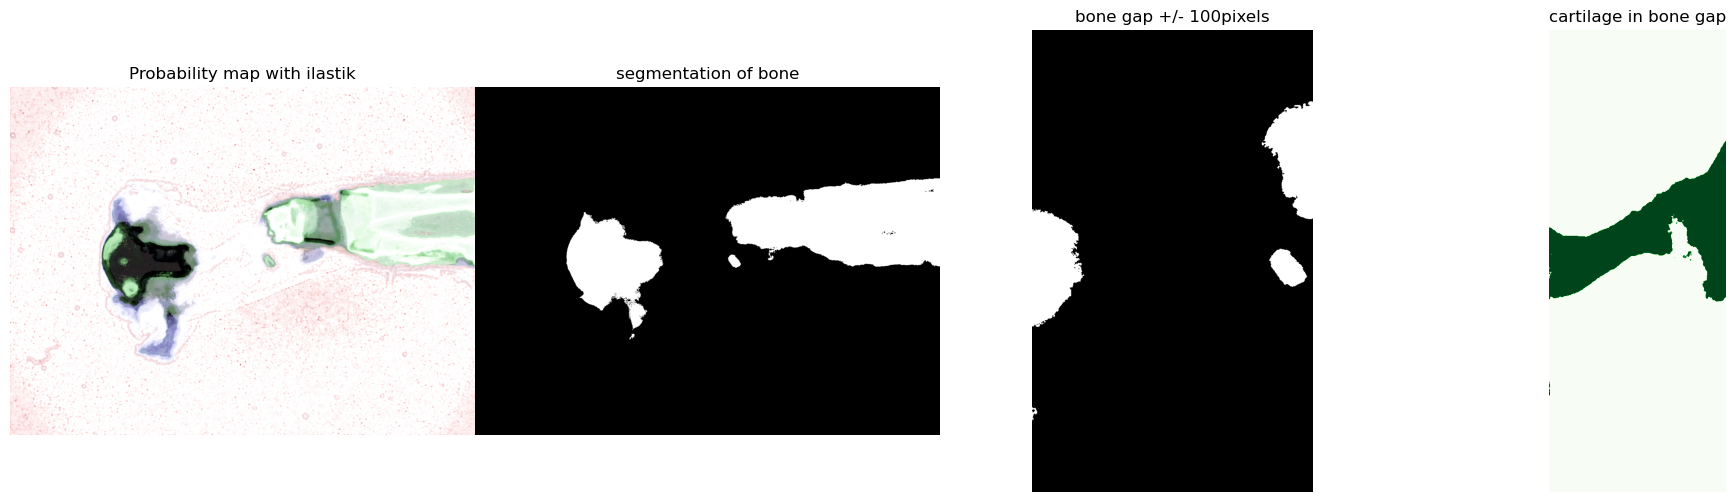

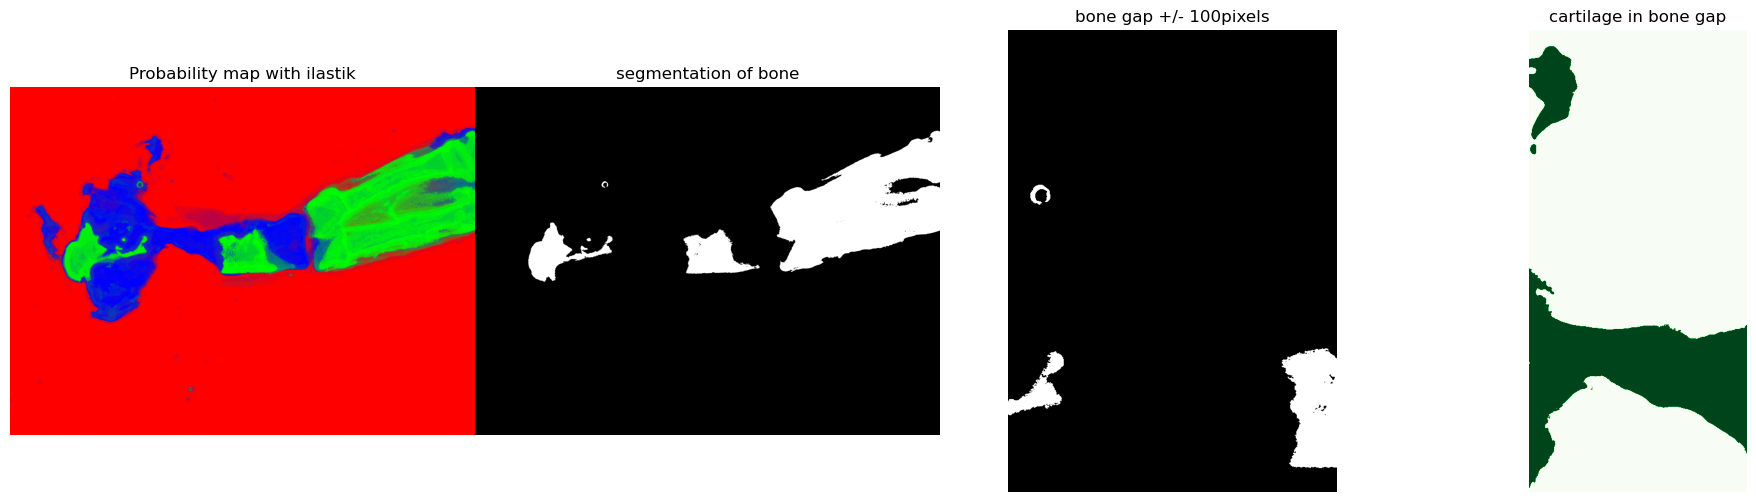

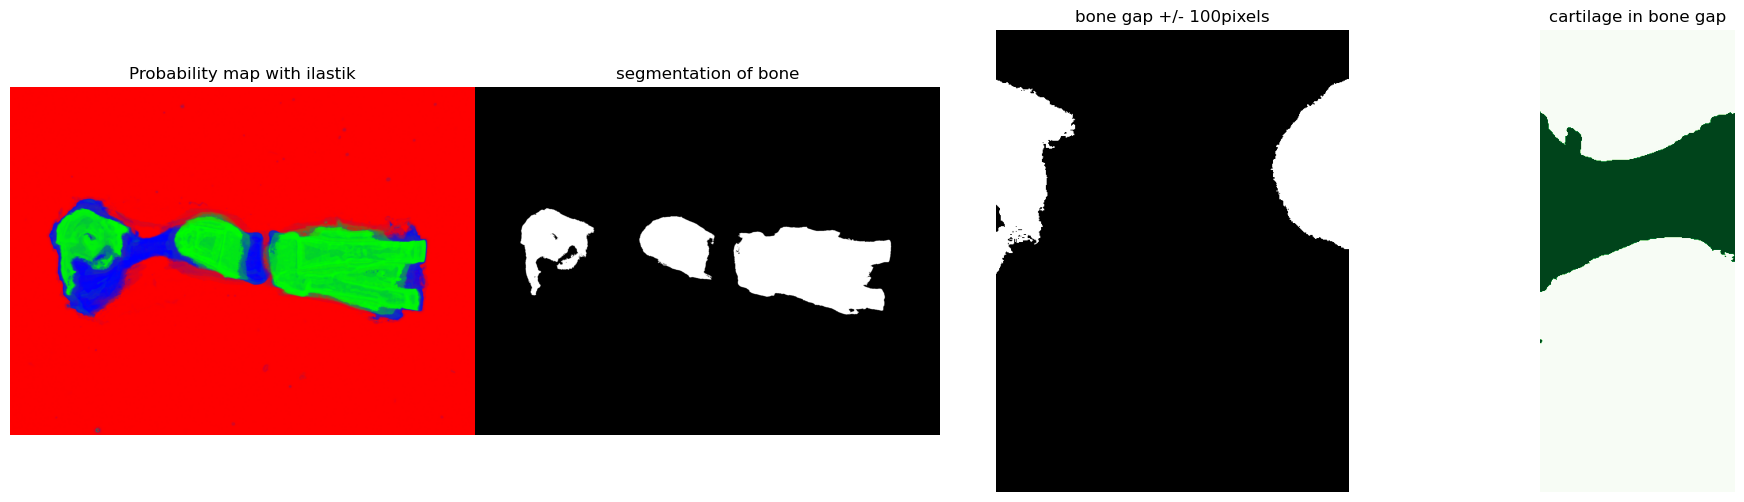

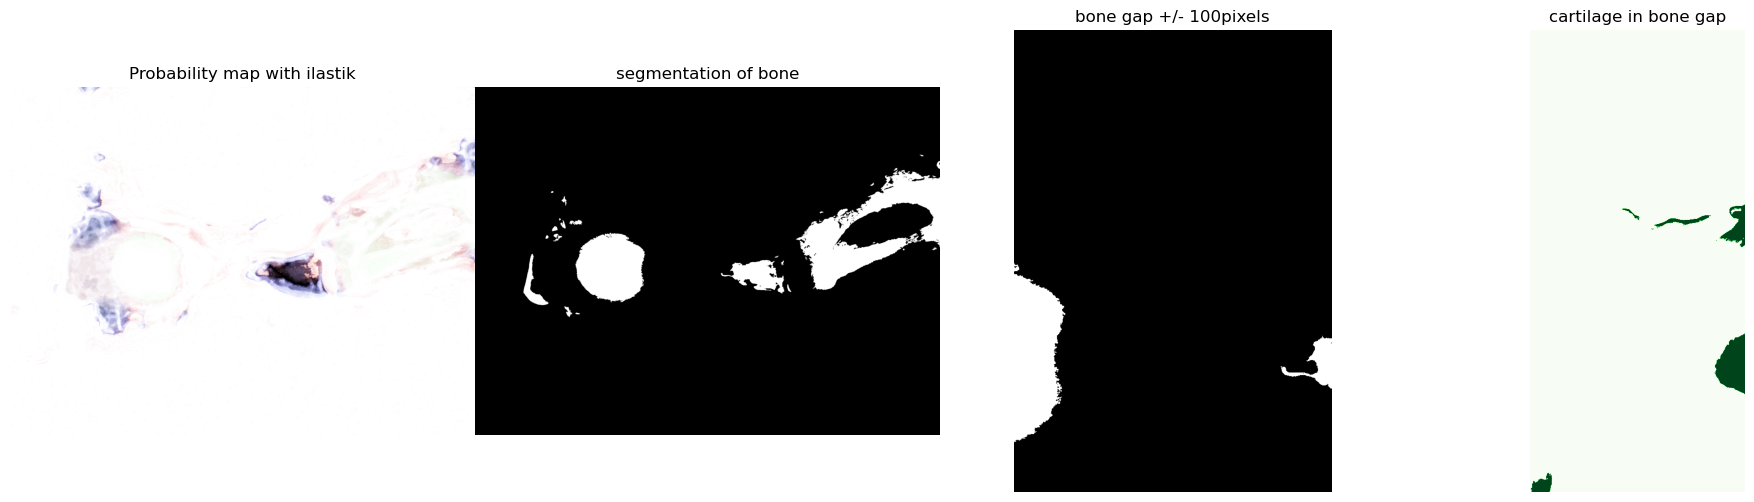

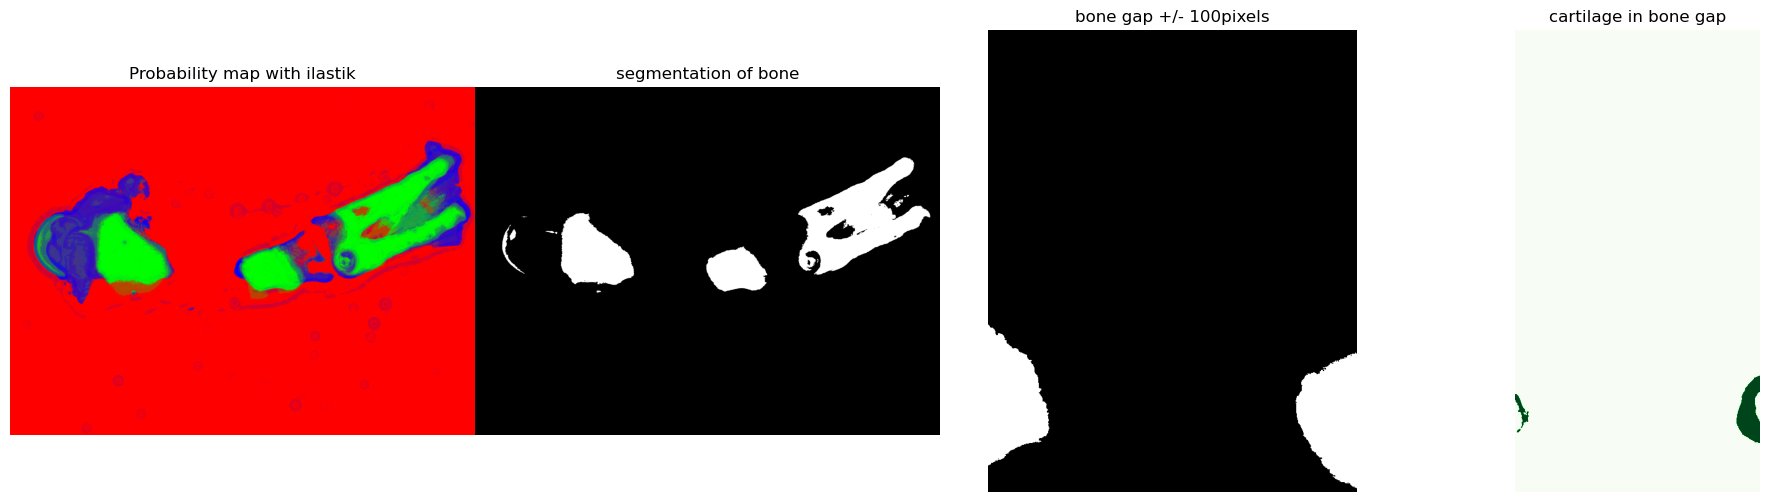

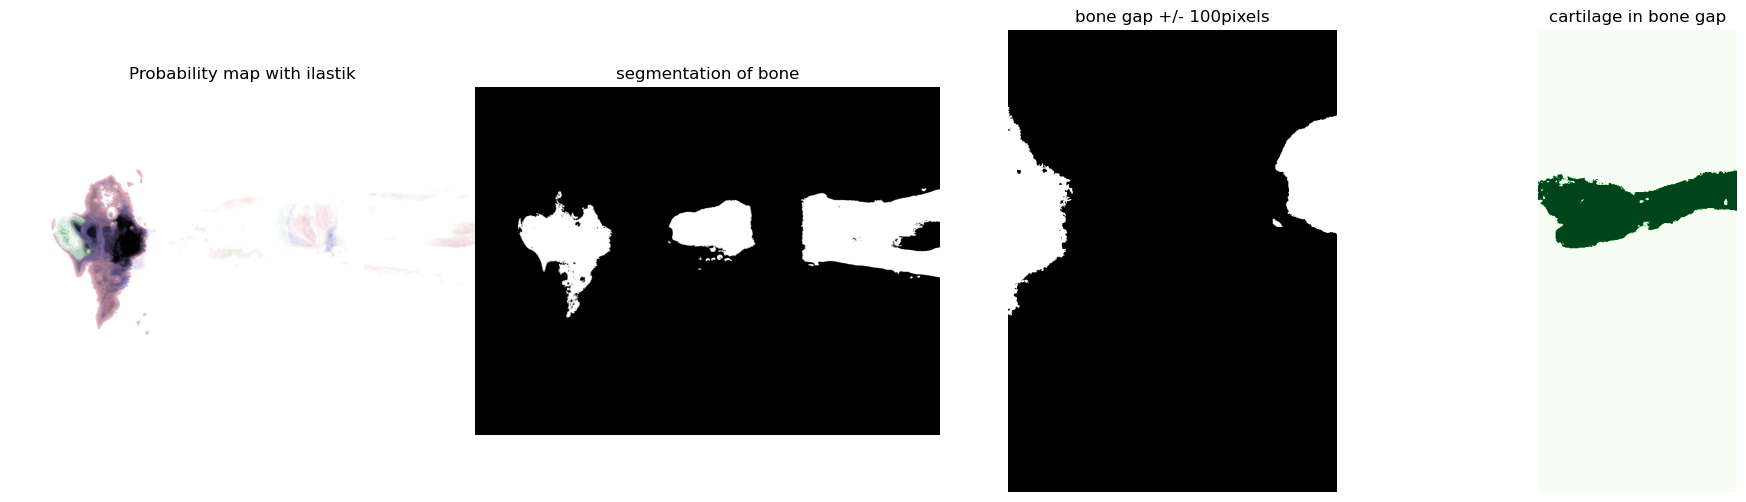

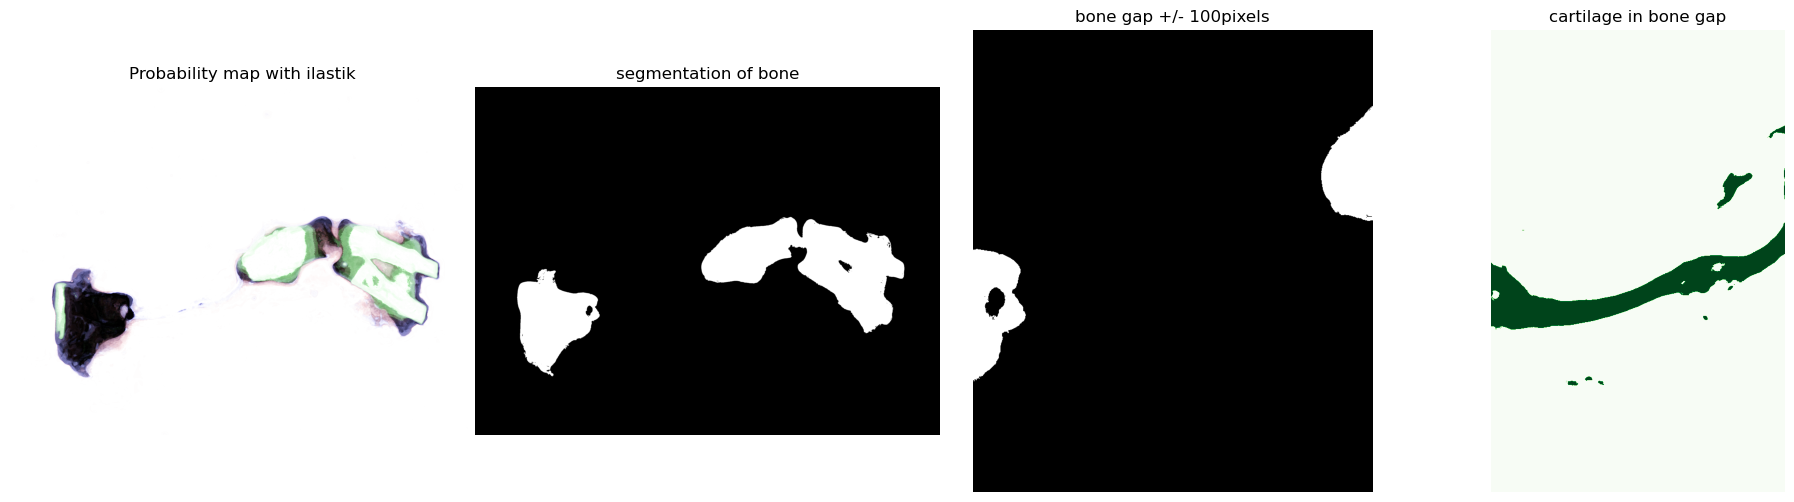

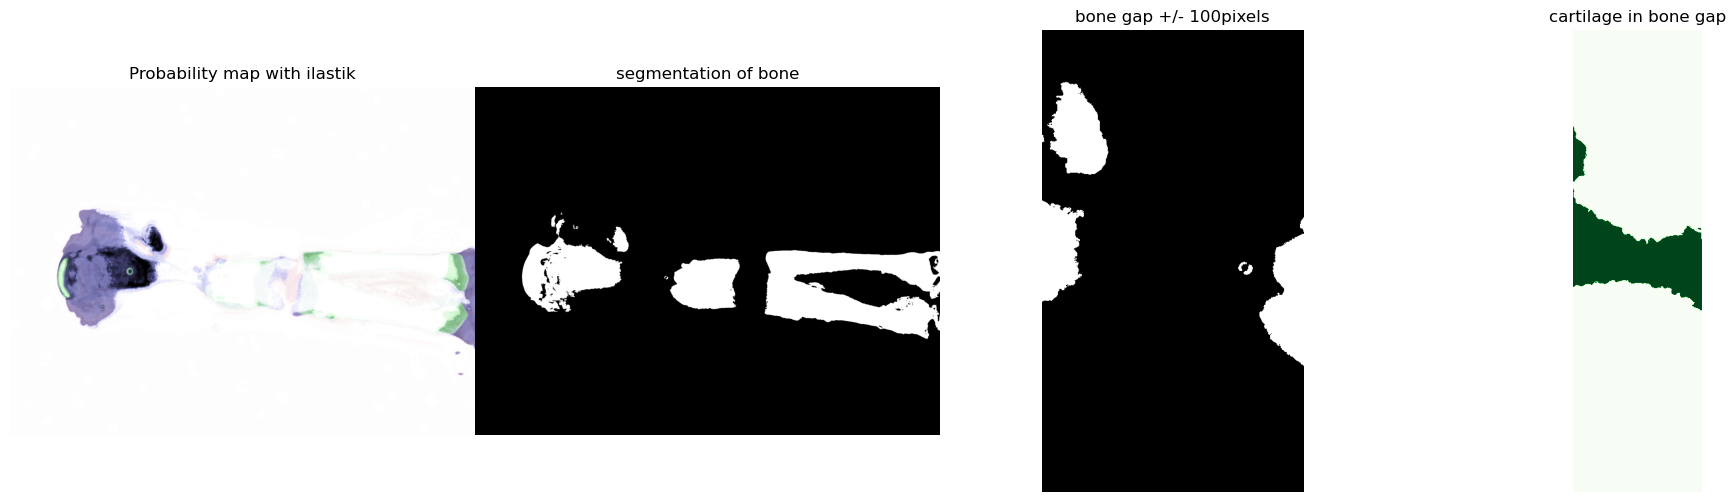

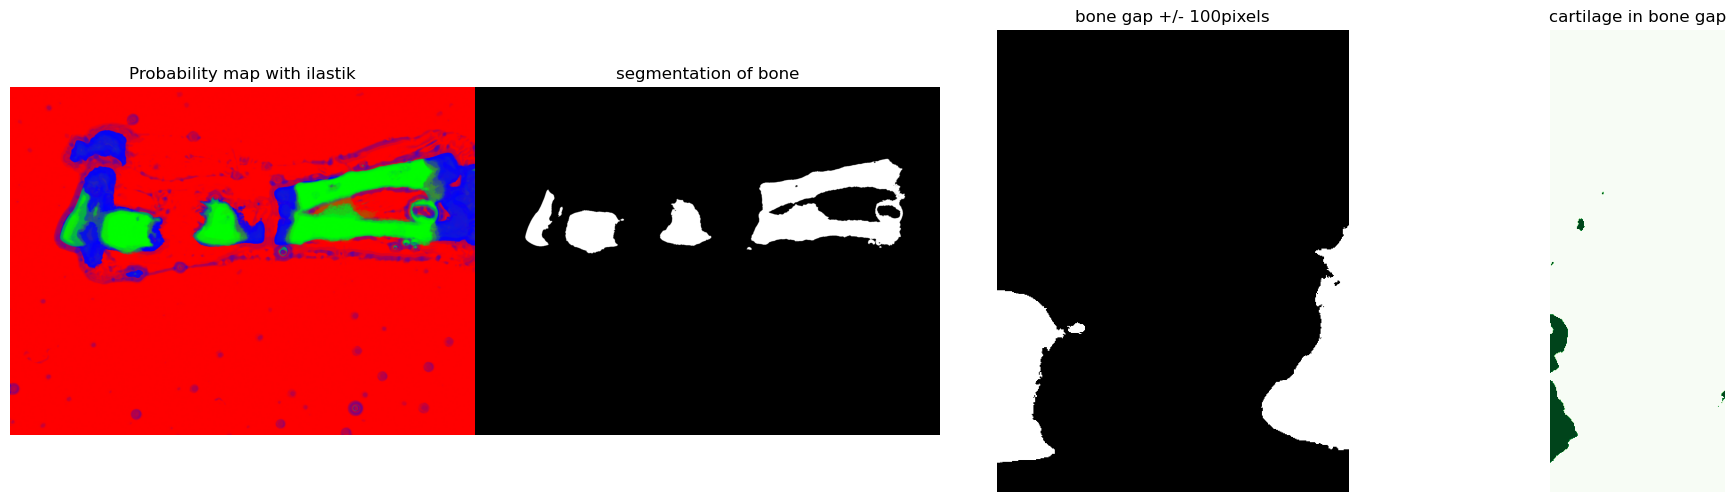

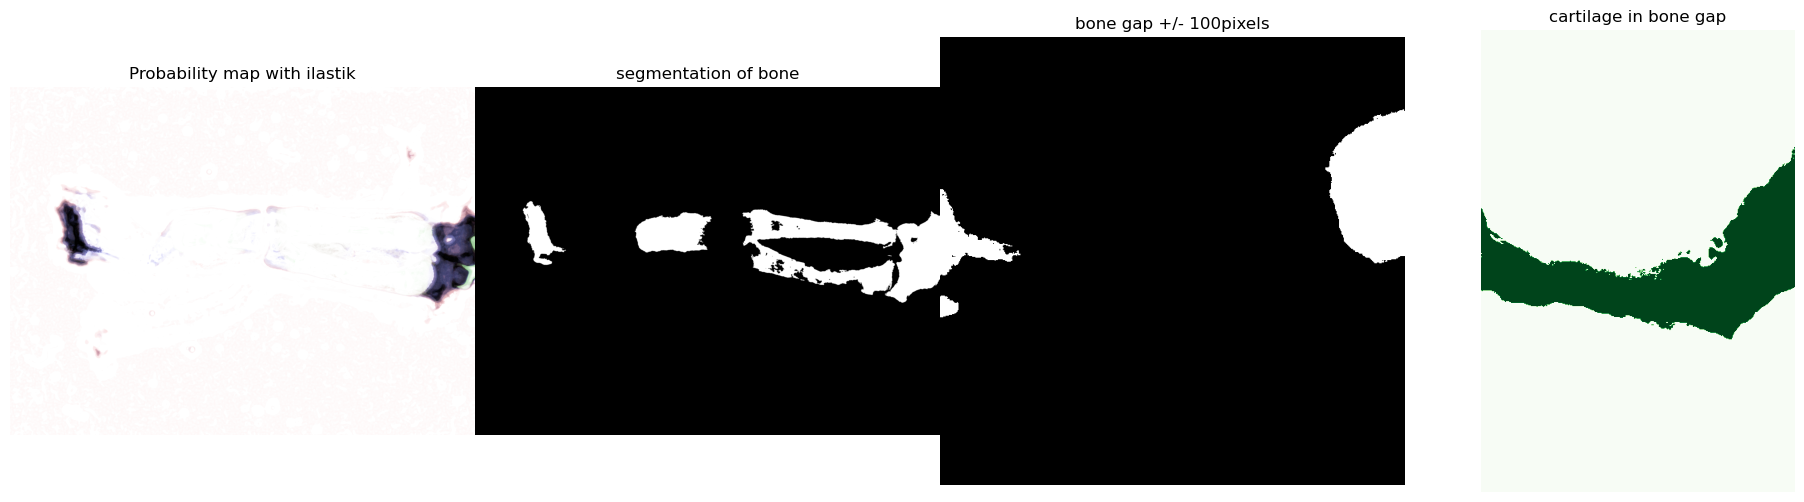

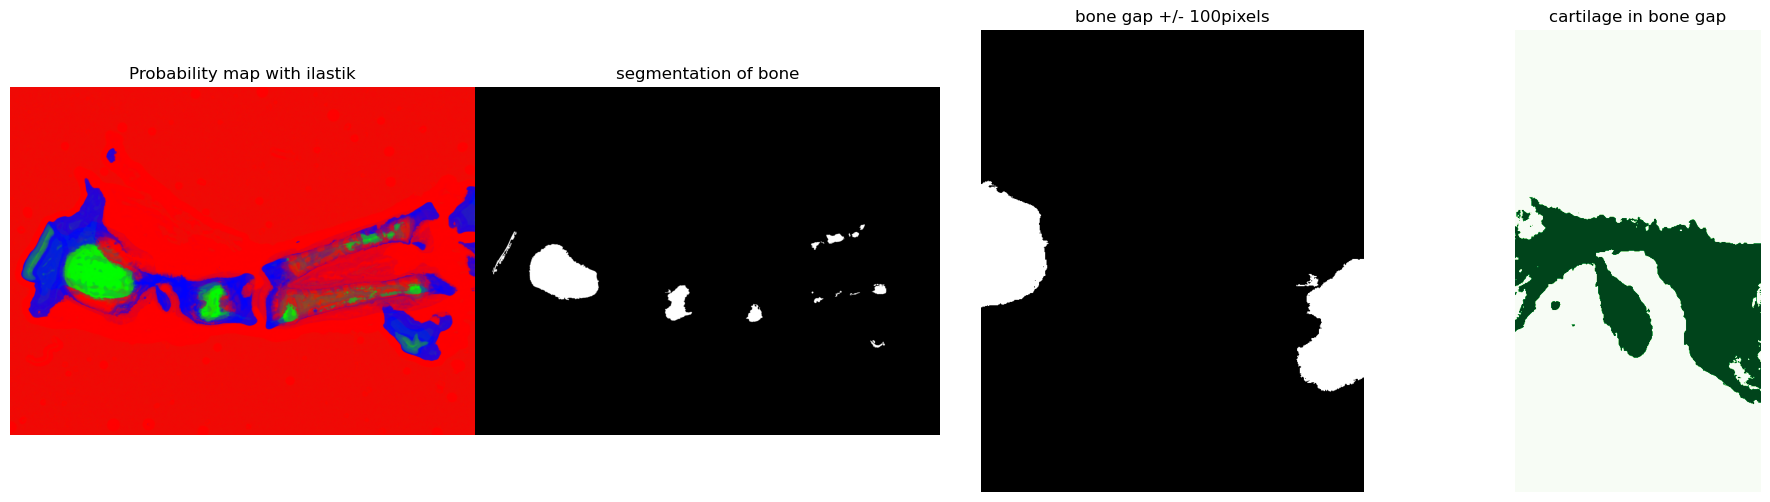

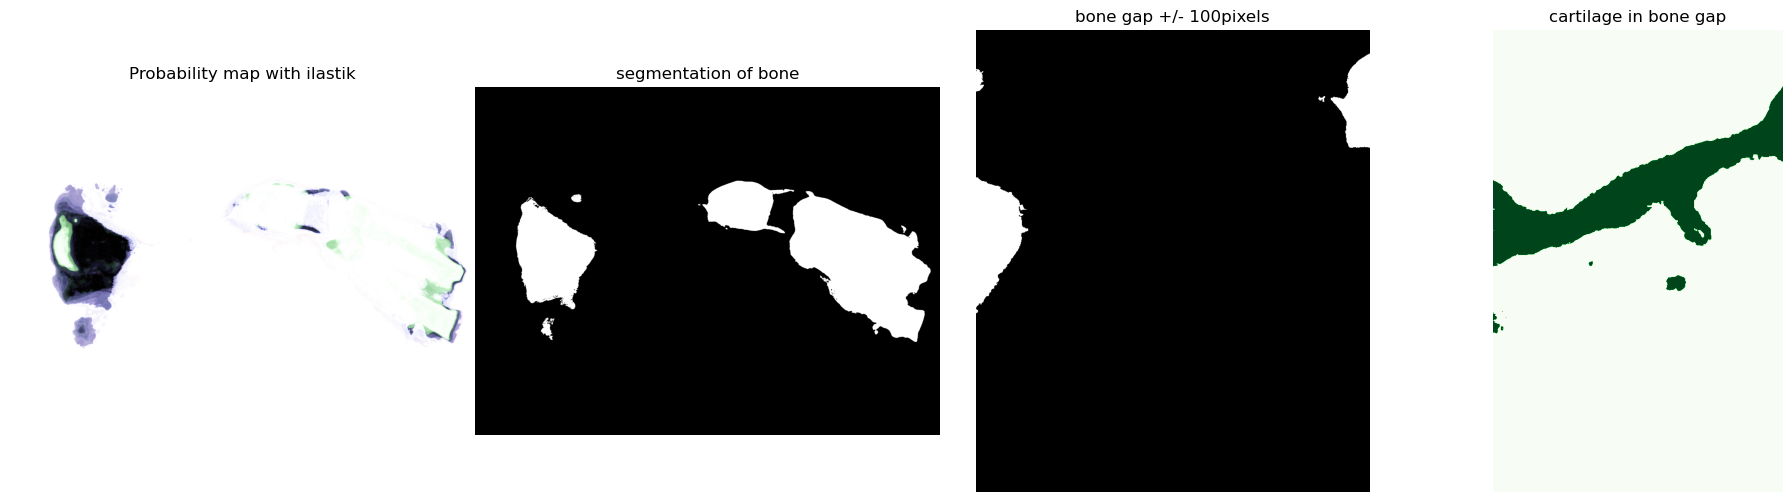

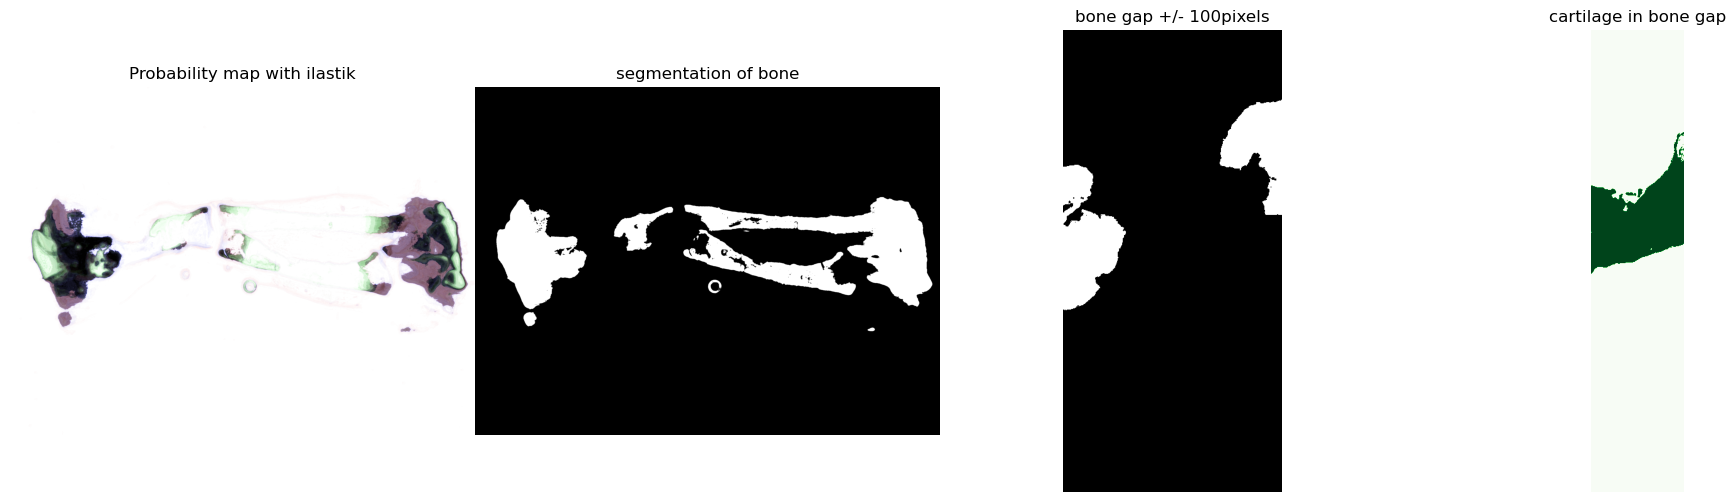

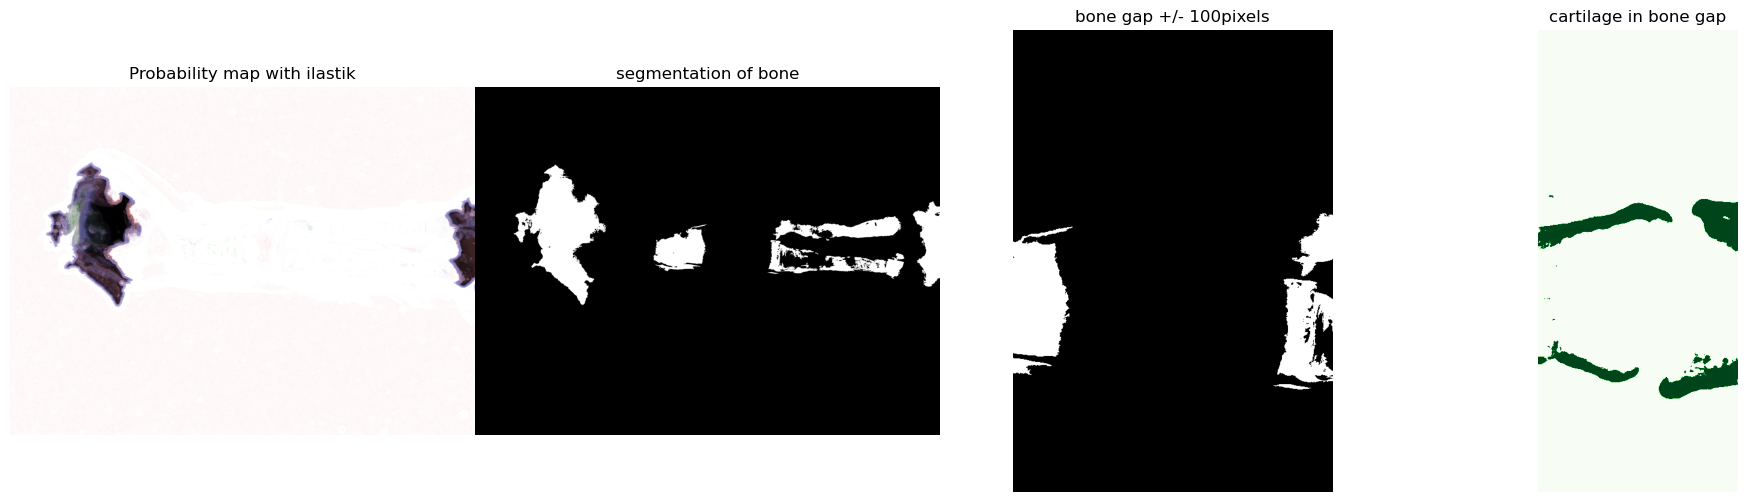

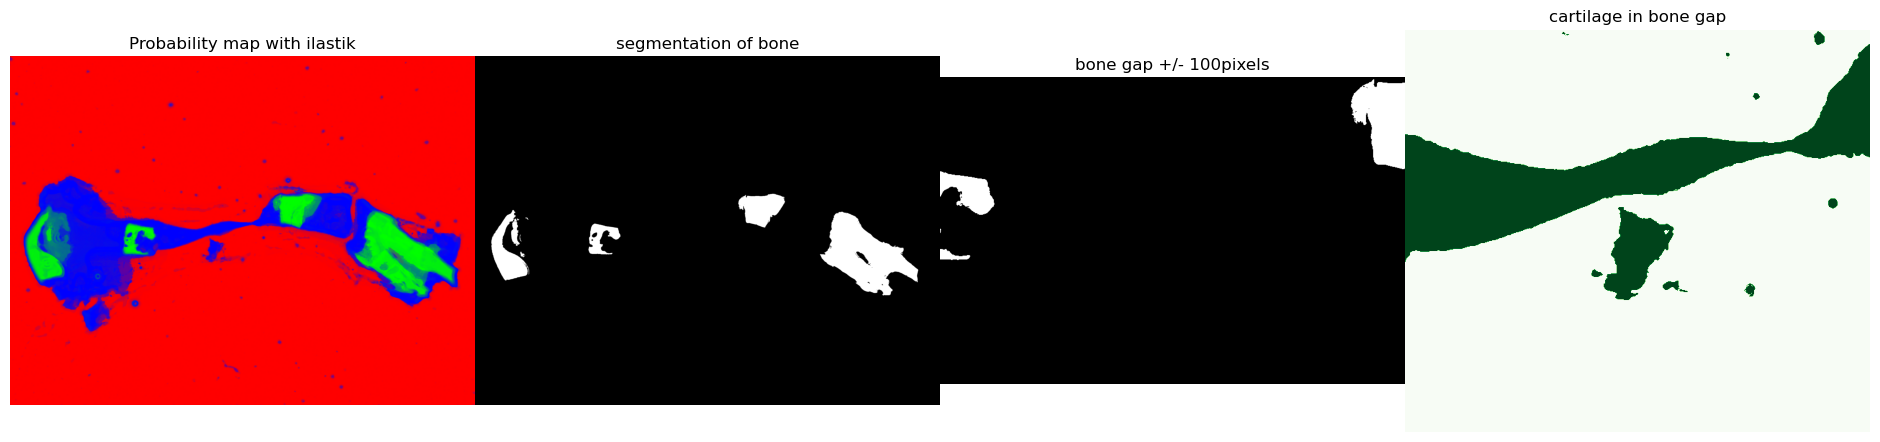

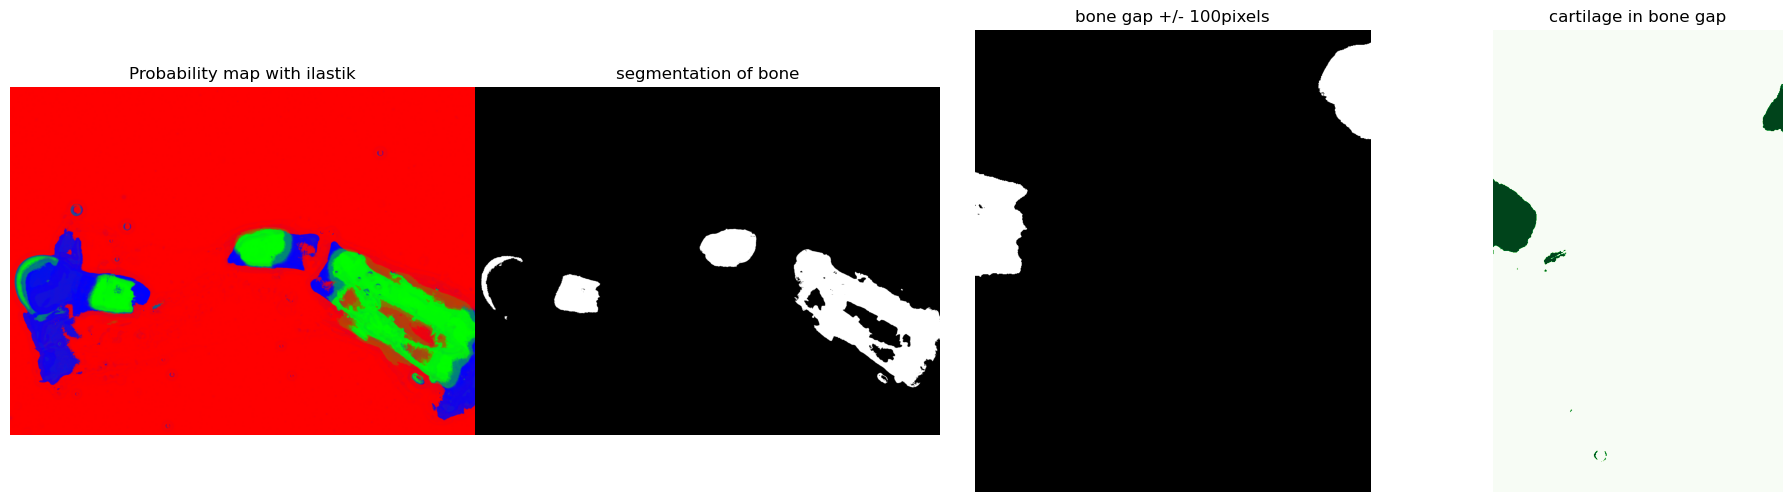

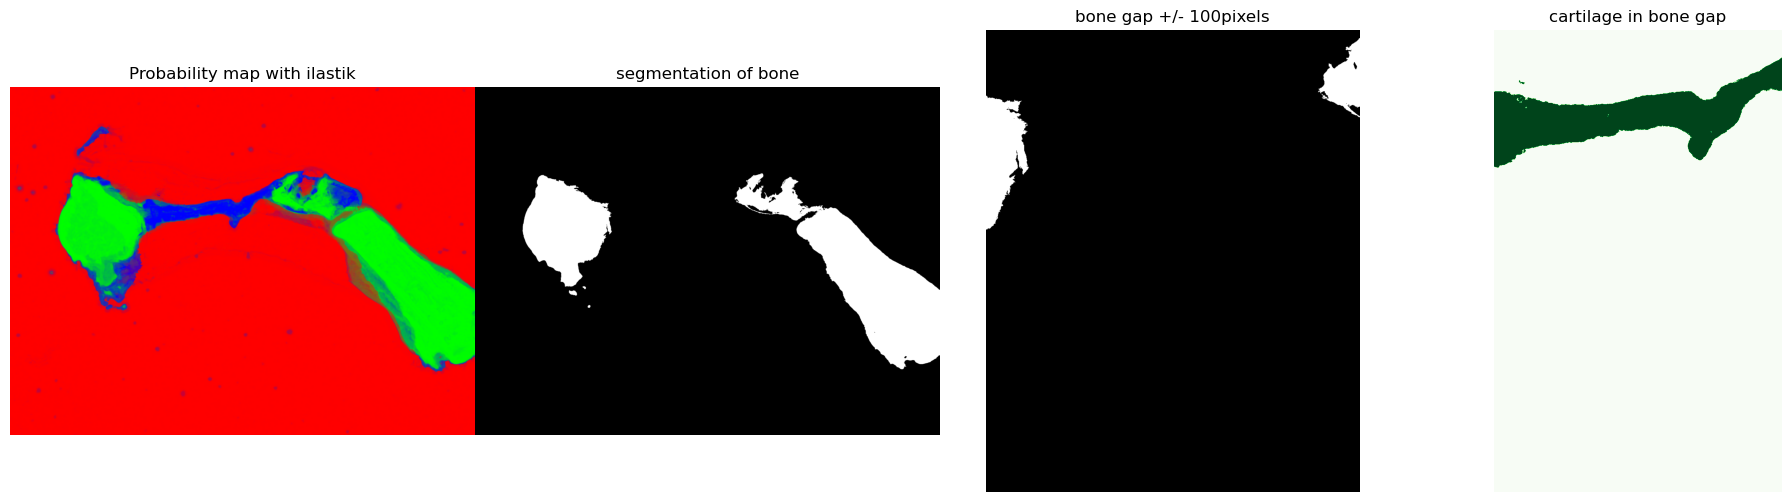

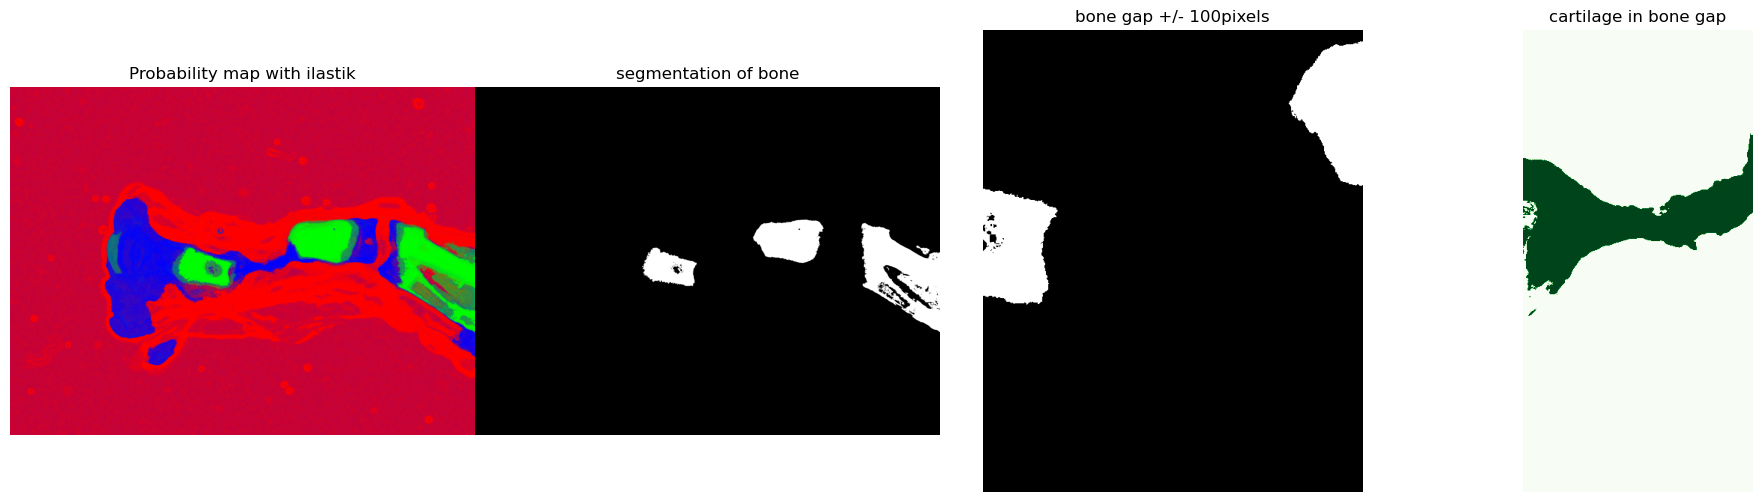

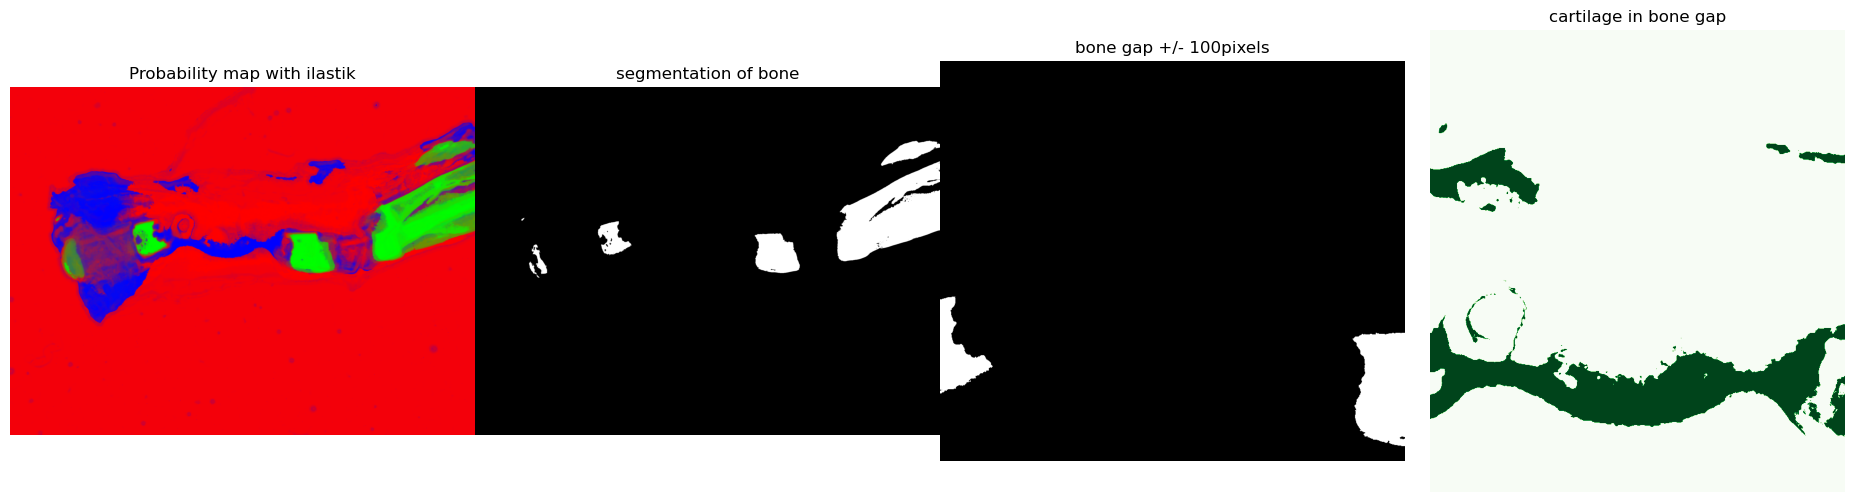

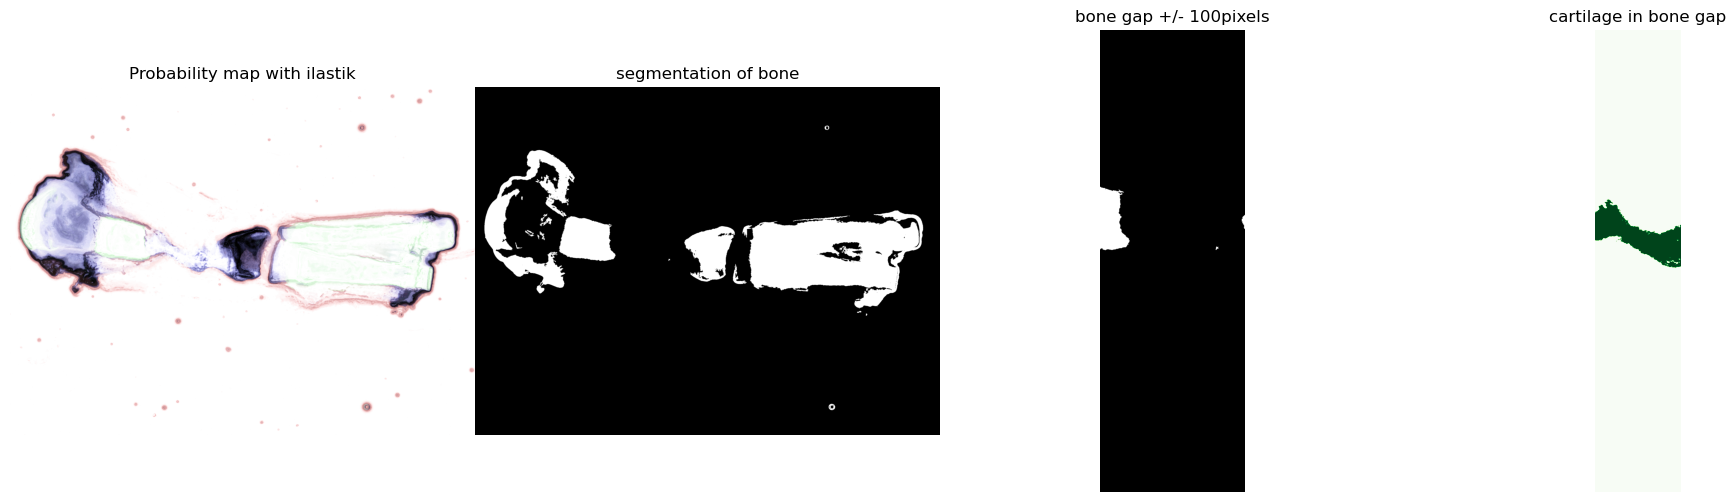

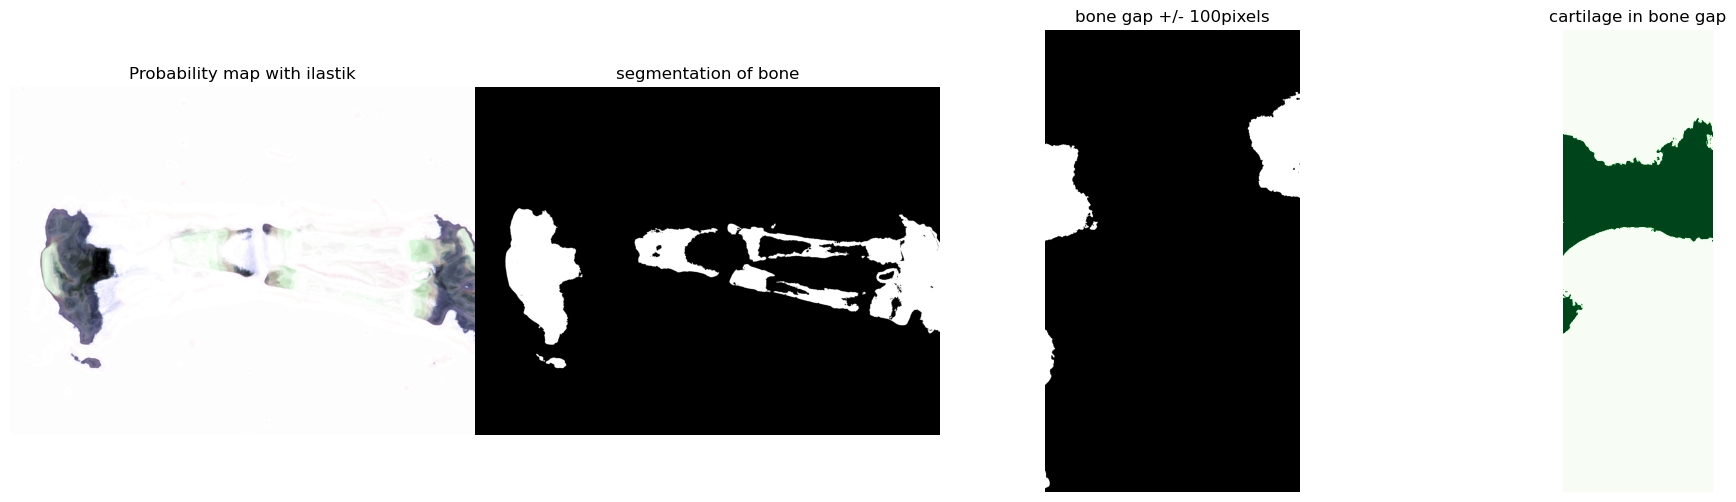

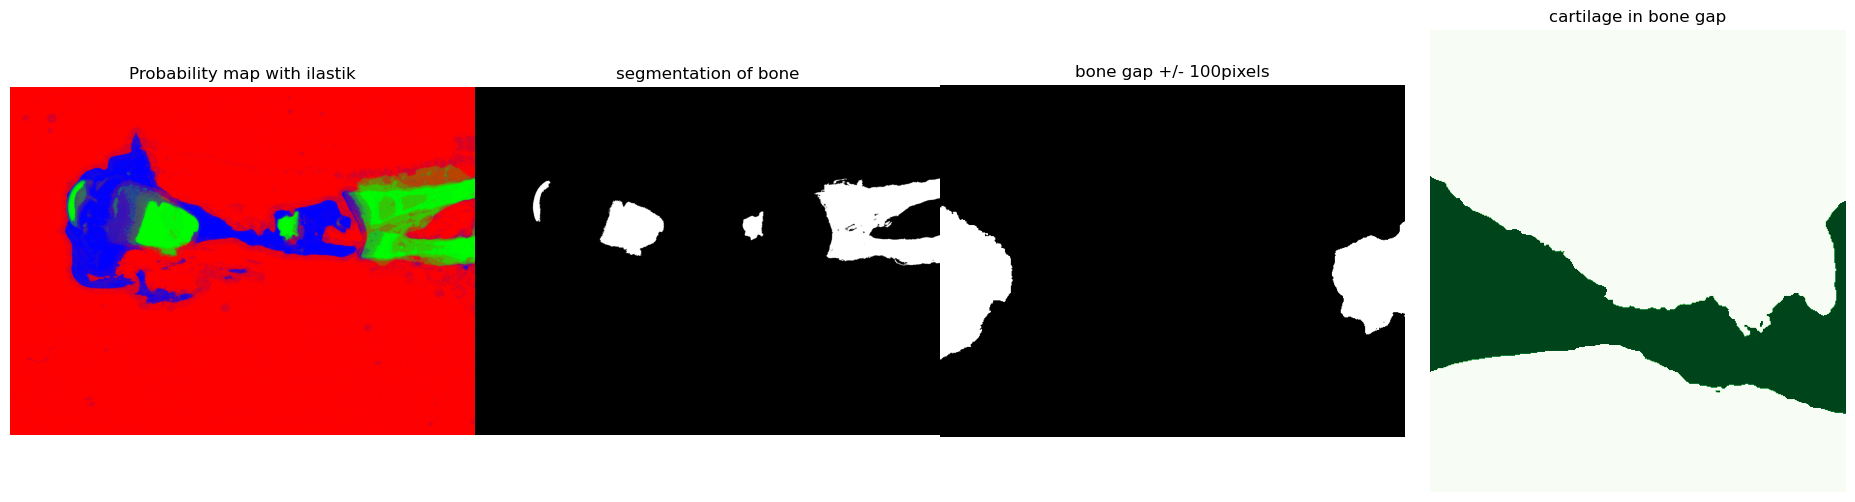

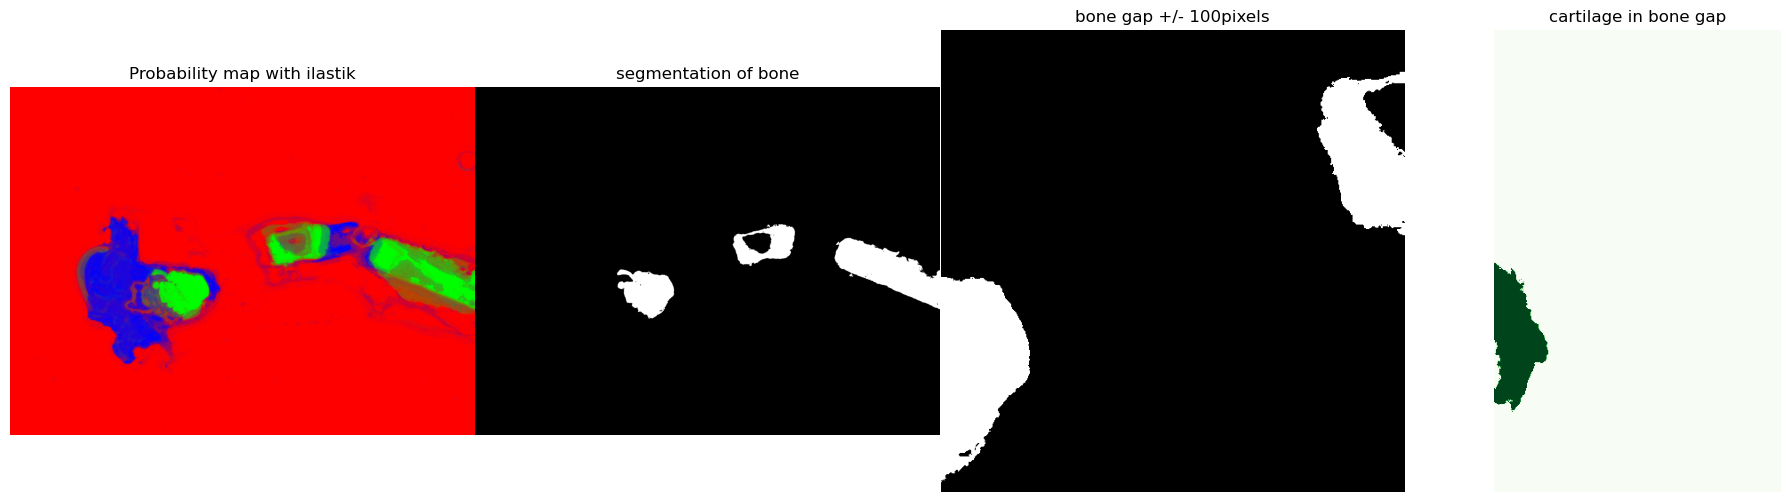

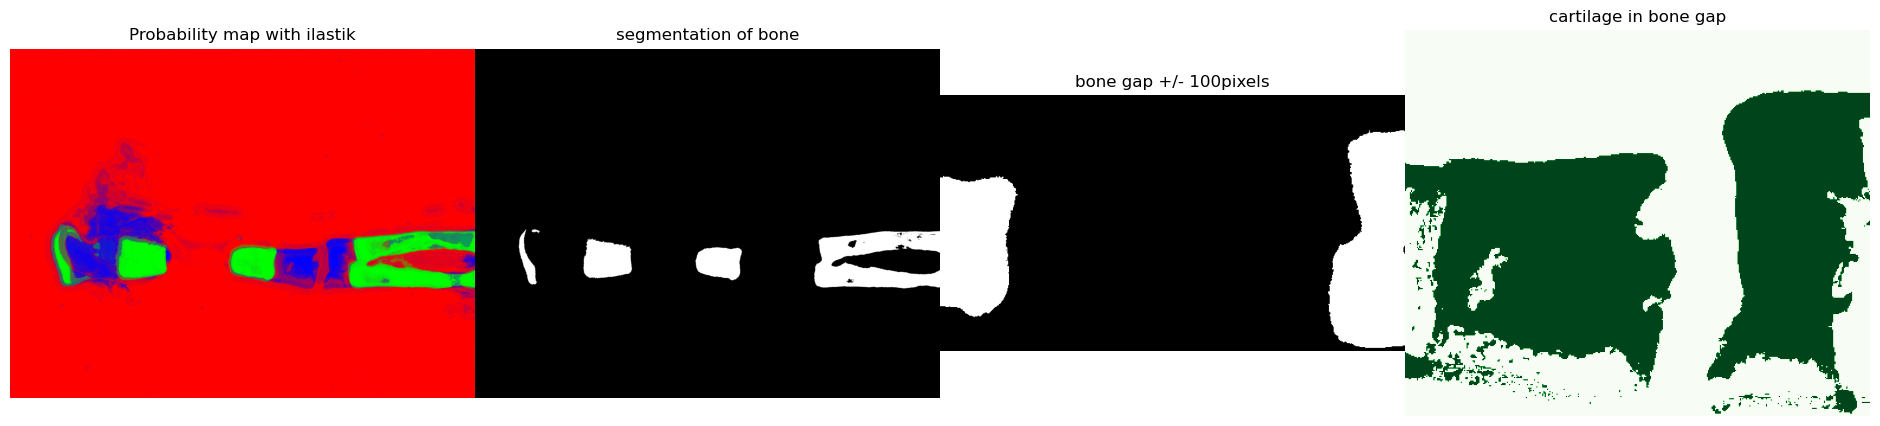

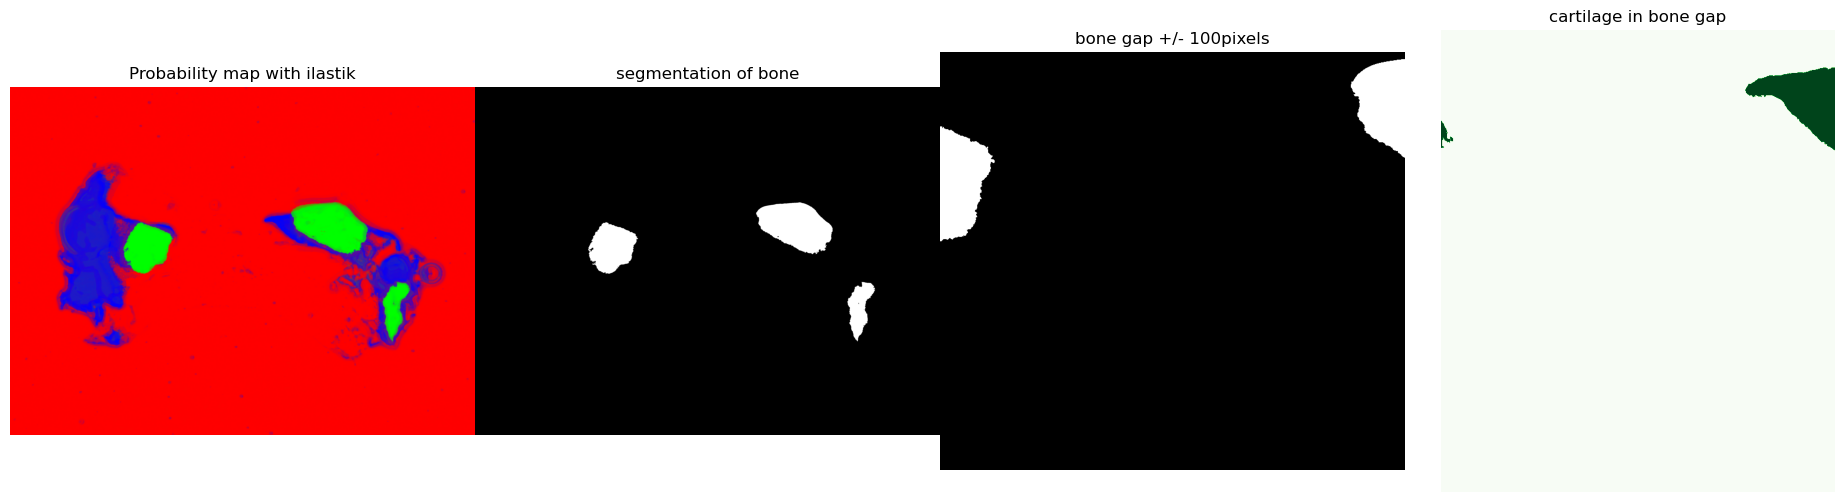

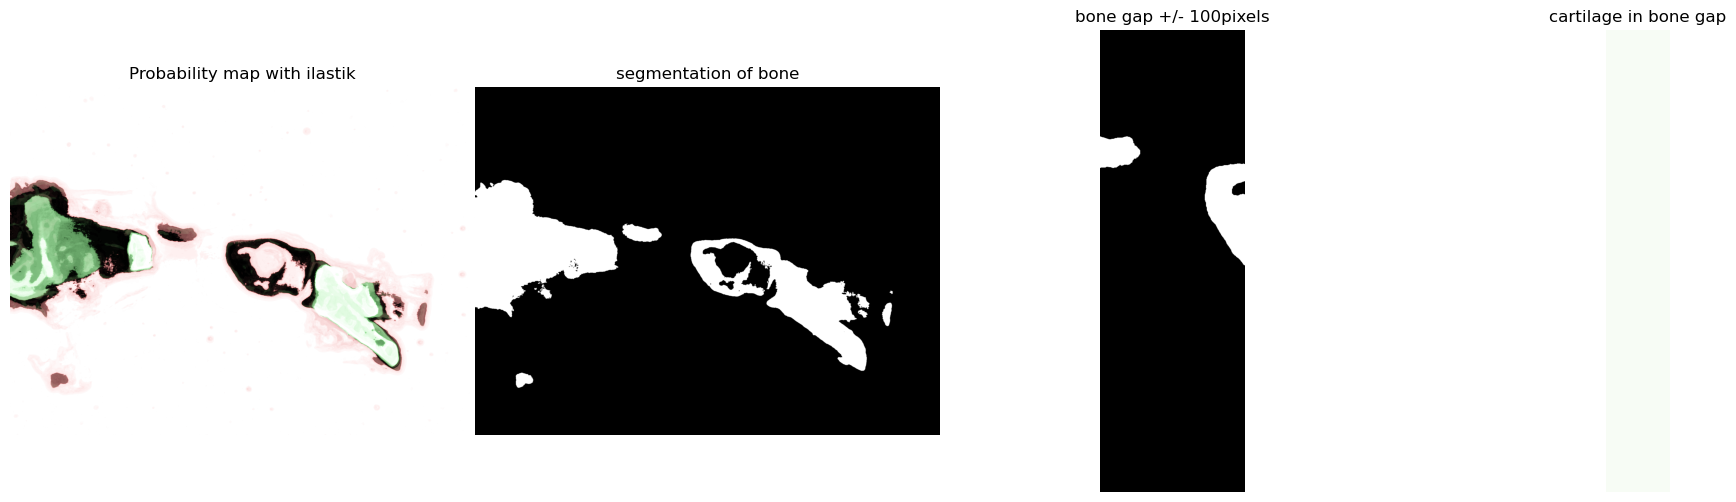

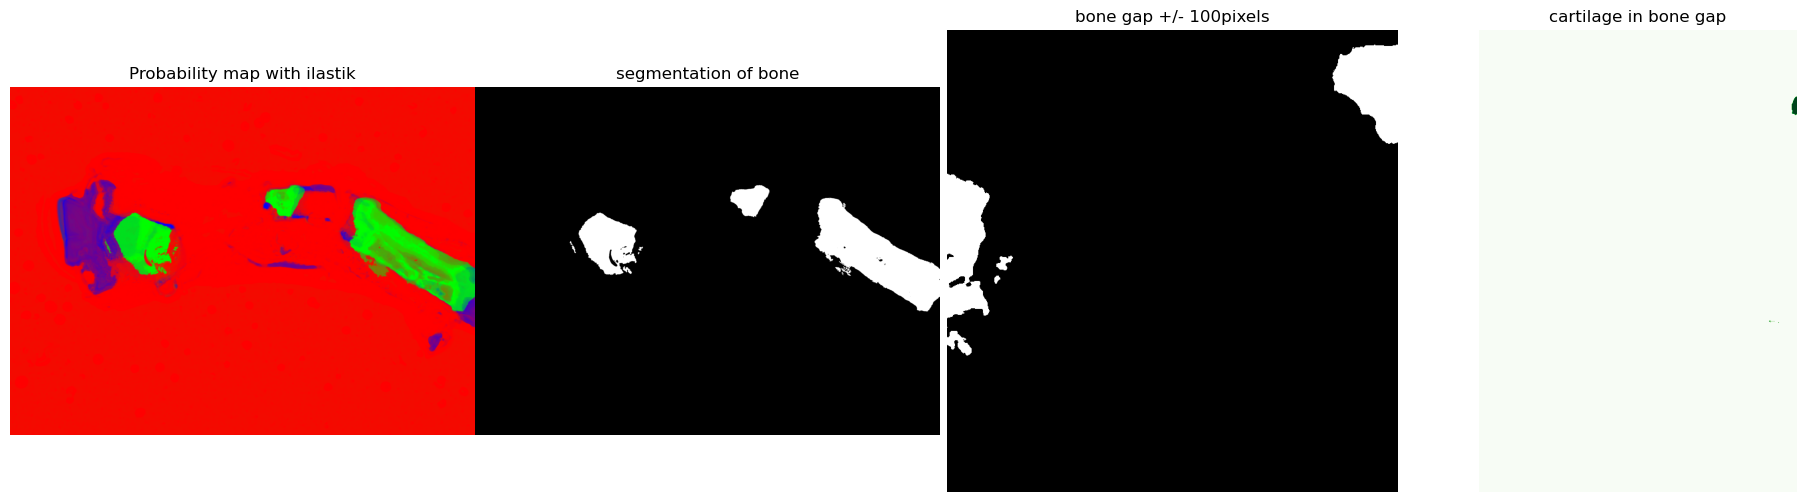

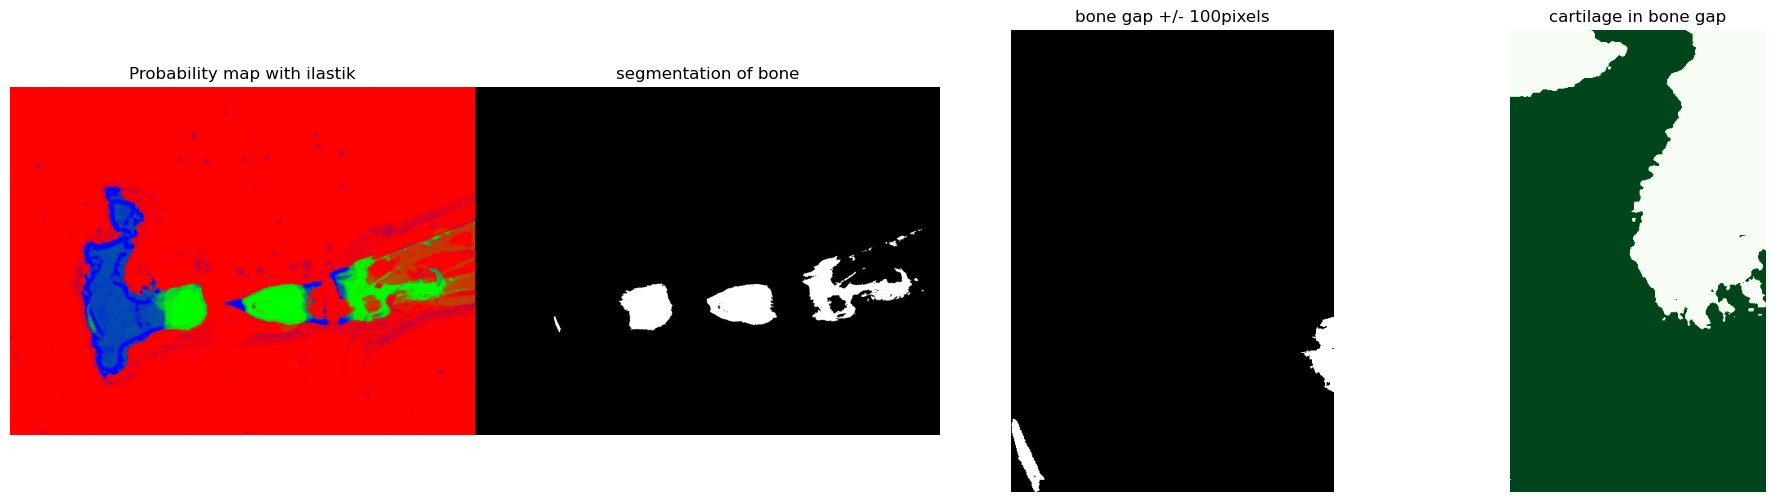

In [47]:
for nm in os.listdir(inputDir):
    #if "C4_CystMask.tiff" in nm:
    if "_Probabilities.tif" in nm:
        #print(nm)
        #fileName = nm.replace('_C4_CystMask.tiff','')
        fileName = nm.replace('_Probabilities.tif','')
        
        img_prob = imread(os.path.join(inputDir, nm))
        
        print(nm, img_prob.shape)
        
        # define masks for bone and cartilage; in this batch, the old bones are sometimes labelled with two channels 2 and 4; channel 3 for segmented cartilage 
        if img_prob.shape[2] > 3: 
            bone_mask = (img_prob[:, :, 1] +  img_prob[:, :, 3])> 0.5
        else:
            bone_mask = img_prob[:, :, 1] > 0.5
            
        cart_mask = img_prob[:, :, 2] > 0.5;
        
        #bone_mask = img_prob[:, :, 0] > 0.7
        #cart_mask = img_prob[:, :, 1] > 0.8
        
        bone_mask = morphology.remove_small_objects(bone_mask, min_size=64)
        
        ## cropping the image for the segmentation
        rowsum = bone_mask.sum(axis=1);
        idx_row = np.where(rowsum > 0)
        colsum = bone_mask.sum(axis=0);
        idx_col = np.where(colsum > 0)
        
        bone_mask_cropped = bone_mask[np.min(idx_row):np.max(idx_row), np.min(idx_col):np.max(idx_col)]
        cart_mask_cropped = cart_mask[np.min(idx_row):np.max(idx_row), np.min(idx_col):np.max(idx_col)]
        
        ## detect the bone gaps and gap border 
        colsum = bone_mask_cropped.sum(axis=0);
        idx_col = np.where(colsum == 0)
        #colsum2 = cart_mask_cropped.sum(axis = 0)
        gap_idx = find_max_gap(idx_col[0])
        length_bone = len(gap_idx)
        
        ## zoom in the gap region 
        bone_len = 100
        if np.min(gap_idx) < bone_len:
            bone_len = np.min(gap_idx)
            
        bone_mask_gap = bone_mask_cropped[:, (np.min(gap_idx)-bone_len):(np.max(gap_idx) + bone_len)]
        
        from scipy.signal import argrelextrema
        pct_cutPlan = 1/3
        
        ## left bone cutting plane 
        bone_left = bone_mask_cropped[:, (np.min(gap_idx)-bone_len):(np.min(gap_idx))]
        colsum_left = bone_left.sum(axis=0)
        colsum_left = colsum_left[::-1]
        #print(colsum_left[0:99])
        diff = abs(colsum_left - np.max(colsum_left) * pct_cutPlan)

        dist_left = argrelextrema(diff, np.less)[0][0]
        #print(dist_left)
        
        ## right bone cutting plane
        bone_right = bone_mask_cropped[:, (np.max(gap_idx)):(np.max(gap_idx) + bone_len)]
        colsum_right = bone_right.sum(axis=0)
        #colsum_right = colsum_right[::-1]
        #print(colsum_right)
        diff_right = abs(colsum_right - np.max(colsum_right) * pct_cutPlan)
        #print(diff.argmin(axis=0))
        dist_right = argrelextrema(diff_right, np.less)[0][0]
        
        #print(dist_right)
        
        ## measure the closure by cartilage within only the bone gap
        cart_mask_gap = cart_mask_cropped[:, (np.min(gap_idx)):(np.max(gap_idx))]
        #cart_mask_gap = cart_mask_cropped[:, (np.min(gap_idx)):(np.max(gap_idx))]
        colsum_cart = cart_mask_gap.sum(axis=0);
        idx_col_cart = np.where(colsum_cart == 0)
        gap_idx_cart = find_max_gap(idx_col_cart[0])
        length_gapCart = len(gap_idx_cart)
        length_gapCart1 = len(idx_col_cart[0])
        
         # Plot
        fig, ax = plt.subplots(1, 4, figsize=(24, 6))
        fig.subplots_adjust(wspace=0)

        ax[0].set_title("Probability map with ilastik")
        ax[0].imshow(img_prob)
        ax[0].set_axis_off()
        ax[1].set_title("segmentation of bone")
        ax[1].imshow(bone_mask, cmap='gray')
        ax[1].set_axis_off()
        ax[2].set_title("bone gap +/- 100pixels")
        ax[2].imshow(bone_mask_gap, cmap='gray')
        ax[2].set_axis_off()

        ax[3].set_title("cartilage in bone gap")
        ax[3].imshow(cart_mask_gap, cmap='Greens')
        ax[3].set_axis_off()
        
        fig.savefig(os.path.join(outDir, str(fileName + "_segmentation_measure.tif")))
        #imsave(, fig)
        #imsave(os.path.join(outDir, str(fileName + "mask_newCartilage.tif")), cart_mask)
        
        
        ## measure the closure by cartilage within bone gaps + left and right cutting plan
        cart_mask_gap = cart_mask_cropped[:, (np.min(gap_idx)-dist_left):(np.max(gap_idx) + dist_right)]
        colsum_cart = cart_mask_gap.sum(axis=0);
        idx_col_cart = np.where(colsum_cart == 0)
        gap_idx_cart2 = find_max_gap(idx_col_cart[0])
        length_gapCart2 = len(gap_idx_cart2)
        length_gapCart3 = len(idx_col_cart[0])
        
        #print(length_gapCart, length_bone, dist_left, dist_right)
        pct_closed = 1 - length_gapCart/(length_bone + dist_left + dist_right)
        #print(pct_closed)
        
        pct_closed1 = 1 - length_gapCart1/(length_bone + dist_left + dist_right)
        #print(pct_closed1)
        
        #print(length_gapCart2, length_bone, dist_left, dist_right)
        pct_closed2 = 1 - length_gapCart2/(length_bone + dist_left + dist_right)
        #print(pct_closed2)
        
        pct_closed3 = 1 - length_gapCart3/(length_bone + dist_left + dist_right)
        print(str(pct_closed) + ' ' + str(pct_closed1) + '  ' + str(pct_closed2) + '  ' +  str(pct_closed3))
        
        
        df.loc[len(df)] = [fileName, length_bone, dist_left, dist_right, length_gapCart, length_gapCart1, length_gapCart2, length_gapCart3, pct_closed, pct_closed1, pct_closed2, pct_closed3 ]
        

In [48]:
df.to_csv(os.path.join(outDir, "ilastik_segmentation_pct_closure.csv"), index=True, header=True)

In [ ]:
##################################
### manually cropping for some images
##################################

In [218]:
outDir = '/Volumes/groups/tanaka/People/current/jiwang/projects/image_analysis/axolotl_limb_CSD/export190326/results/manual_cropping'

if not os.path.exists(outDir):
    os.makedirs(outDir)

print(outDir)

/Volumes/groups/tanaka/People/current/jiwang/projects/image_analysis/axolotl_limb_CSD/export190326/results/manual_cropping


In [401]:
fileName = '4w-1x-LNP5-6'
fileName = '4w-1x-LNP5-4' 
fileName = '4w-1x-LNP5-2' 
fileName = '4w-1x-LNP4-4'  
fileName = '4w-1x-LNP4-3'
fileName = '4w-1x-LNP3-4'
fileName = '4w-1x-LNP3-2'
fileName = '4w-1x-LNP2-3'
fileName = '4w-1x-LNP2-2'
fileName = '4w-1x-LNP1-2'
fileName = '4w-1x-LNP-WTIG-1'
fileName = '4w-1x-LNP-TIG-1'
fileName = '4w-1x-LNP-TIG-2'
fileName = '4w-1x-LNP-WG-1'

In [402]:
data = {"image": [], "bone_gap":[],  "left_cuttingPlan":[], "right_cuttingPlan":[], 
        "cartilage_boneGap":[],  "cartilage_boneGap_2":[], "cartilage_boneCutting":[],   "cartilage_boneCutting_2":[],  
         "pct_closure_1":[],  "pct_closure_2":[], "pct_closure_3":[], "pct_closure_4":[]
       }

df = pd.DataFrame(data)

4w-1x-LNP-WG-1 (1920, 2560, 4)


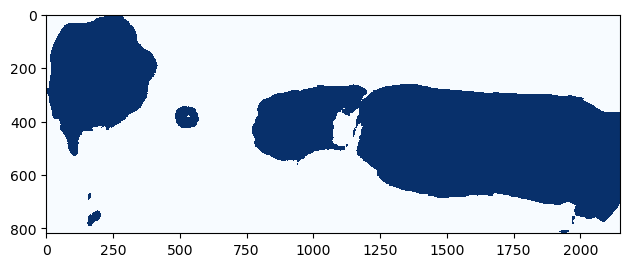

In [450]:
img_prob = imread(os.path.join(inputDir, str(fileName) + '_Probabilities.tif'))
        
print(fileName, img_prob.shape)
        
# define masks for bone and cartilage; in this batch, the old bones are sometimes labelled with two channels 2 and 4; channel 3 for segmented cartilage 
if img_prob.shape[2] > 3: 
    bone_mask = (img_prob[:, :, 1] +  img_prob[:, :, 3])> 0.5
else:
    bone_mask = img_prob[:, :, 1] > 0.5
            
cart_mask = img_prob[:, :, 2] > 0.5;

bone_mask = morphology.remove_small_objects(bone_mask, min_size=64)

## cropping the image for the segmentation
rowsum = bone_mask.sum(axis=1);
idx_row = np.where(rowsum > 0)

colsum = bone_mask.sum(axis=0);
idx_col = np.where(colsum > 0)

bone_mask_cropped = bone_mask[np.min(idx_row):np.max(idx_row), np.min(idx_col):np.max(idx_col)]
cart_mask_cropped = cart_mask[np.min(idx_row):np.max(idx_row), np.min(idx_col):np.max(idx_col)]
imshow(bone_mask_cropped, cmap="Blues")

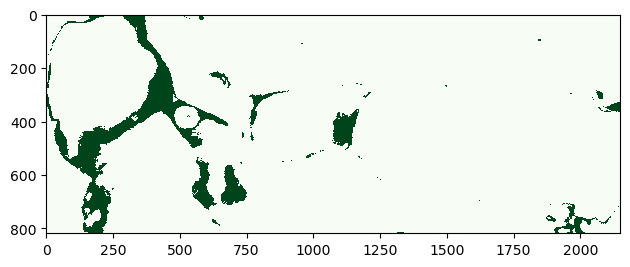

In [451]:
imshow(cart_mask_cropped, cmap="Greens")

In [452]:
bone_mask_cropped.shape, cart_mask_cropped.shape

((819, 2149), (819, 2149))

In [453]:
### here is manual cropping by specifying the y-axis and x-axis
bone_mask_cropped = bone_mask_cropped[275:480, 250:1000]
cart_mask_cropped = cart_mask_cropped[275:480, 250:1000]

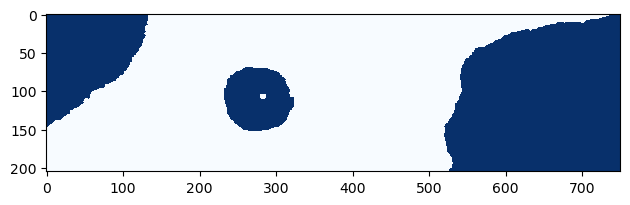

In [454]:
imshow(bone_mask_cropped, cmap="Blues")

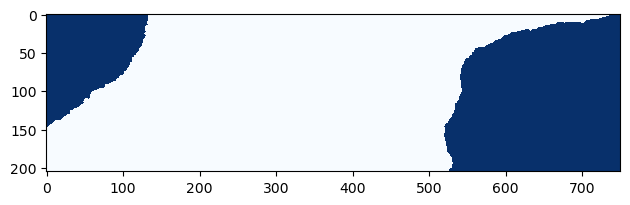

In [455]:
bone_mask_cropped[:, 220:400] = 0
imshow(bone_mask_cropped, cmap="Blues")

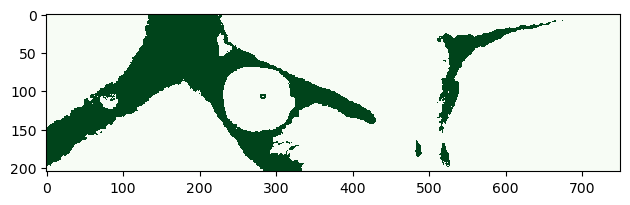

In [456]:
imshow(cart_mask_cropped, cmap="Greens")

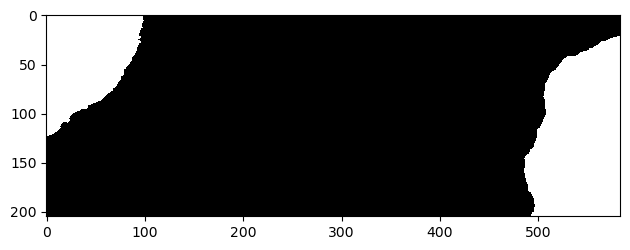

In [457]:
## detect the bone gaps and gap border 
colsum = bone_mask_cropped.sum(axis=0);
idx_col = np.where(colsum == 0)
#colsum2 = cart_mask_cropped.sum(axis = 0)
gap_idx = find_max_gap(idx_col[0])
length_bone = len(gap_idx)

## zoom in the gap region 
bone_len = 100
if np.min(gap_idx) < bone_len:
    bone_len = np.min(gap_idx)
    
bone_mask_gap = bone_mask_cropped[:, (np.min(gap_idx)-bone_len):(np.max(gap_idx) + bone_len)]
imshow(bone_mask_gap, cmap="gray")

0.8793103448275862 0.8300492610837439  0.8793103448275862  0.8300492610837439


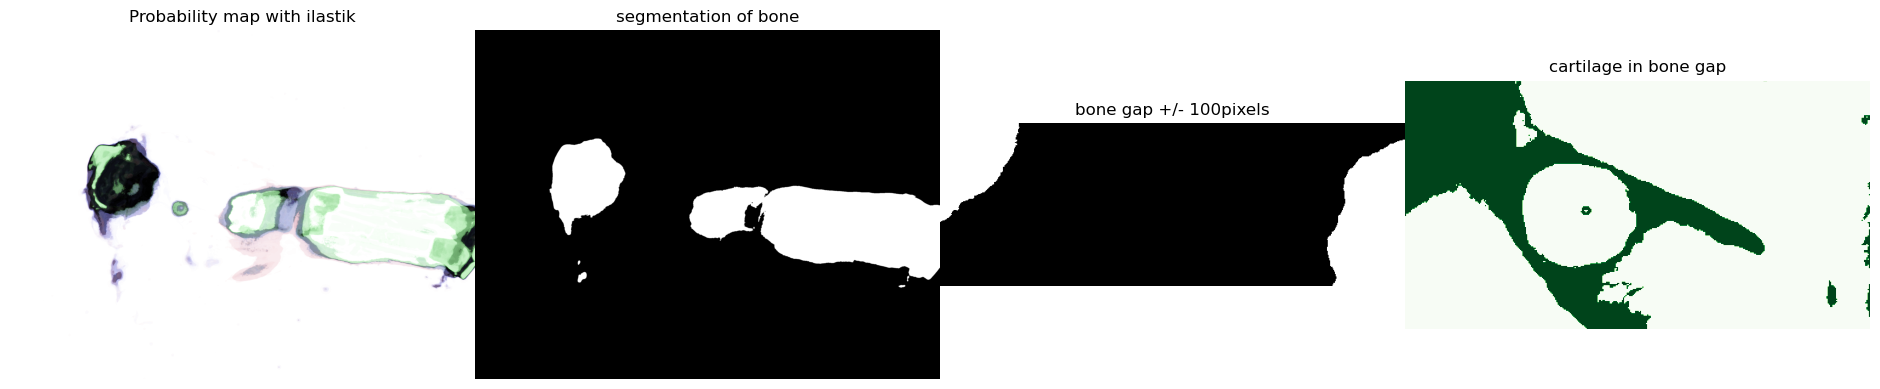

In [458]:
from scipy.signal import argrelextrema
pct_cutPlan = 1/3
        
## left bone cutting plane 
bone_left = bone_mask_cropped[:, (np.min(gap_idx)-bone_len):(np.min(gap_idx))]
colsum_left = bone_left.sum(axis=0)
colsum_left = colsum_left[::-1]
#print(colsum_left[0:99])
diff = abs(colsum_left - np.max(colsum_left) * pct_cutPlan)

dist_left = argrelextrema(diff, np.less)[0][0]
#print(dist_left)
        
## right bone cutting plane
bone_right = bone_mask_cropped[:, (np.max(gap_idx)):(np.max(gap_idx) + bone_len)]
colsum_right = bone_right.sum(axis=0)
#colsum_right = colsum_right[::-1]
#print(colsum_right)
diff_right = abs(colsum_right - np.max(colsum_right) * pct_cutPlan)
#print(diff.argmin(axis=0))
dist_right = argrelextrema(diff_right, np.less)[0][0]
        
#print(dist_right)
        
## measure the closure by cartilage within only the bone gap
cart_mask_gap = cart_mask_cropped[:, (np.min(gap_idx)):(np.max(gap_idx))]
#cart_mask_gap = cart_mask_cropped[:, (np.min(gap_idx)):(np.max(gap_idx))]
colsum_cart = cart_mask_gap.sum(axis=0);
idx_col_cart = np.where(colsum_cart == 0)
gap_idx_cart = find_max_gap(idx_col_cart[0])
length_gapCart = len(gap_idx_cart)
length_gapCart1 = len(idx_col_cart[0])
        
# Plot
fig, ax = plt.subplots(1, 4, figsize=(24, 6))
fig.subplots_adjust(wspace=0)

ax[0].set_title("Probability map with ilastik")
ax[0].imshow(img_prob)
ax[0].set_axis_off()
ax[1].set_title("segmentation of bone")
ax[1].imshow(bone_mask, cmap='gray')
ax[1].set_axis_off()
ax[2].set_title("bone gap +/- 100pixels")
ax[2].imshow(bone_mask_gap, cmap='gray')
ax[2].set_axis_off()

ax[3].set_title("cartilage in bone gap")
ax[3].imshow(cart_mask_gap, cmap='Greens')
ax[3].set_axis_off()
        
fig.savefig(os.path.join(outDir, str(fileName + "_segmentation_measure.tif")))
#imsave(, fig)
#imsave(os.path.join(outDir, str(fileName + "mask_newCartilage.tif")), cart_mask)
        
        
## measure the closure by cartilage within bone gaps + left and right cutting plan
cart_mask_gap = cart_mask_cropped[:, (np.min(gap_idx)-dist_left):(np.max(gap_idx) + dist_right)]
colsum_cart = cart_mask_gap.sum(axis=0);
idx_col_cart = np.where(colsum_cart == 0)
gap_idx_cart2 = find_max_gap(idx_col_cart[0])
length_gapCart2 = len(gap_idx_cart2)
length_gapCart3 = len(idx_col_cart[0])
        
#print(length_gapCart, length_bone, dist_left, dist_right)
pct_closed = 1 - length_gapCart/(length_bone + dist_left + dist_right)
#print(pct_closed)
        
pct_closed1 = 1 - length_gapCart1/(length_bone + dist_left + dist_right)
#print(pct_closed1)
        
#print(length_gapCart2, length_bone, dist_left, dist_right)
pct_closed2 = 1 - length_gapCart2/(length_bone + dist_left + dist_right)
#print(pct_closed2)
        
pct_closed3 = 1 - length_gapCart3/(length_bone + dist_left + dist_right)
print(str(pct_closed) + ' ' + str(pct_closed1) + '  ' + str(pct_closed2) + '  ' +  str(pct_closed3))
        
        
df.loc[len(df)] = [fileName, length_bone, dist_left, dist_right, length_gapCart, length_gapCart1, length_gapCart2, length_gapCart3, pct_closed, pct_closed1, pct_closed2, pct_closed3 ]
df.to_csv(os.path.join(outDir, str(fileName) + "ilastik_segmentation_pct_closure.csv"), index=True, header=True)

In [459]:
colsum_cart 

array([ 80,  79,  85,  86,  89,  92,  99, 104, 110, 112, 110, 110, 109,
       109, 107, 106, 106, 105, 105, 104, 103, 103, 102, 101, 101, 100,
       101, 100,  99,  97,  97,  96,  95,  95,  95,  96,  95,  94,  94,
        94,  93,  93,  93,  92,  91,  91,  92,  92,  93,  92,  91,  90,
        89,  87,  86,  87,  88,  89,  89,  90,  92,  93,  95,  98,  98,
        97,  98, 100, 100, 101, 102, 101,  99,  98, 100, 101, 102, 103,
       107, 107, 108, 109, 110, 112, 113, 113, 114, 115, 115, 116, 118,
       119, 122, 124, 125, 128, 129, 131, 131, 127, 123, 107, 107, 106,
       103, 101,  92,  82,  82,  74,  65,  63,  60,  53,  53,  51,  55,
        53,  56,  54,  52,  51,  53,  50,  47,  46,  51,  52,  51,  51,
        50,  51,  51,  51,  53,  54,  54,  55,  53,  54,  54,  54,  55,
        53,  54,  55,  55,  55,  55,  54,  55,  55,  54,  55,  58,  63,
        65,  65,  65,  67,  67,  66,  65,  62,  61,  62,  60,  62,  54,
        55,  52,  52,  46,  41,  40,  41,  42,  42,  40,  42,  4